In [ ]:
#=== HOW DID CONTEMPORARY ARTISTS DEBUT IN MOMA? ===

Total debuts with contemporary works (1999+): 2,872

  Self-donation (artist/architect donated own work): 303 (10.6%)
  External donation (collector brought the work):   1,149 (40.0%)
  Purchase (museum bought):                         1,420 (49.4%)

#=== HOW DID CONTEMPORARY ARTISTS DEBUT IN MOMA's PAINTING & SCULPTURE DEPARTMENT? ===

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import rcParams
import warnings
warnings.filterwarnings('ignore')

# ── STYLE ──────────────────────────────────────────────────────
rcParams['font.family'] = 'Arial'
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['figure.facecolor'] = 'white'
rcParams['axes.facecolor'] = 'white'

RED     = '#E52322'
DARK    = '#1A1814'
MID     = '#5A5650'
LIGHT   = '#8A8680'
GOLD    = '#B8962E'
BLUE    = '#2C5F8A'
GREEN   = '#1E7B42'
PALE    = '#F5F3EE'

# ── LOAD DATA ──────────────────────────────────────────────────
print("Loading MoMA collection data...")
artworks = pd.read_csv('/Users/arousell/collection/Artworks.csv', low_memory=False)
artists  = pd.read_csv('/Users/arousell/collection/Artists.csv',  low_memory=False)

print(f"Artworks: {len(artworks):,}")
print(f"Artists:  {len(artists):,}")
print(f"\nDepartments in collection:")
print(artworks['Department'].value_counts().head(10))

Loading MoMA collection data...
Artworks: 160,597
Artists:  15,921

Departments in collection:
Department
Drawings & Prints                        82099
Architecture & Design                    34561
Photography                              33826
Painting & Sculpture                      4084
Media and Performance                     3295
Fluxus Collection                         1683
Film                                      1018
Architecture & Design - Image Archive       31
Name: count, dtype: int64


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import warnings
warnings.filterwarnings('ignore')

rcParams['font.family'] = 'Arial'
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['figure.facecolor'] = 'white'
rcParams['axes.facecolor'] = 'white'

RED   = '#E52322'
DARK  = '#1A1814'
MID   = '#5A5650'
LIGHT = '#8A8680'
GOLD  = '#B8962E'
BLUE  = '#2C5F8A'
GREEN = '#1E7B42'
PALE  = '#F5F3EE'

artworks = pd.read_csv('/Users/arousell/collection/Artworks.csv', low_memory=False)
artists  = pd.read_csv('/Users/arousell/collection/Artists.csv',  low_memory=False)

artworks['DateAcquired'] = pd.to_datetime(artworks['DateAcquired'], errors='coerce')
artworks['YearAcquired'] = artworks['DateAcquired'].dt.year

def classify_credit(credit):
    if pd.isna(credit): return 'Unknown'
    c = str(credit).lower()
    if 'gift' in c and 'artist' in c: return 'Gift of Artist'
    if 'gift' in c or 'donated' in c: return 'Gift/Donation'
    if 'purchase' in c or 'fund' in c or 'acquired' in c: return 'Purchase/Fund'
    if 'bequest' in c: return 'Bequest'
    if 'exchange' in c: return 'Exchange'
    if 'transfer' in c: return 'Transfer'
    return 'Other'

artworks['EntryType'] = artworks['CreditLine'].apply(classify_credit)

print("Data loaded.")
print(f"Artworks: {len(artworks):,} | Artists: {len(artists):,}")

Data loaded.
Artworks: 160,597 | Artists: 15,921


In [14]:
# WHY PAINTING & SCULPTURE — the numbers

dept_summary = artworks.groupby('Department').agg(
    total_works=('Artist', 'count'),
    unique_artists=('Artist', 'nunique')
).reset_index()

recent = artworks[artworks['YearAcquired'].between(2019, 2026)]
recent_dept = recent.groupby('Department').size().reset_index(name='recent_works')
dept_summary = dept_summary.merge(recent_dept, on='Department', how='left')
dept_summary['recent_works'] = dept_summary['recent_works'].fillna(0).astype(int)
dept_summary['pct_total'] = dept_summary['total_works'] / len(artworks) * 100
dept_summary = dept_summary.sort_values('total_works', ascending=False)

print("=" * 65)
print("WHY PAINTING & SCULPTURE")
print("=" * 65)

print(f"\n{'Department':<35} {'Works':>7} {'% Total':>8} {'Artists':>8} {'2019-26':>8}")
print("-" * 70)
for _, row in dept_summary.iterrows():
    print(f"  {row['Department']:<33} {row['total_works']:>7,} "
          f"{row['pct_total']:>7.1f}% {row['unique_artists']:>8,} "
          f"{row['recent_works']:>8,}")

ps_all   = artworks[artworks['Department'] == 'Painting & Sculpture'].copy()
ps_recent = recent[recent['Department'] == 'Painting & Sculpture'].copy()
other_recent = recent[recent['Department'] != 'Painting & Sculpture'].copy()

print(f"\n── P&S STRUCTURAL FACTS ───────────────────────────────────")
print(f"  Total works:         {len(ps_all):,}")
print(f"  Unique artists:      {ps_all['Artist'].nunique():,}")
print(f"  Year range:          {ps_all['YearAcquired'].min():.0f} – {ps_all['YearAcquired'].max():.0f}")

print(f"\n── ENTRY TYPES: P&S vs ALL OTHER DEPTS (2019-2026) ───────")
ps_entry    = ps_recent['EntryType'].value_counts()
other_entry = other_recent['EntryType'].value_counts()

print(f"\n  P&S ({len(ps_recent):,} works):")
for k, v in ps_entry.items():
    print(f"    {k:<22} {v:>5,}  ({v/len(ps_recent)*100:.1f}%)")

print(f"\n  Other departments ({len(other_recent):,} works):")
for k, v in other_entry.items():
    print(f"    {k:<22} {v:>5,}  ({v/len(other_recent)*100:.1f}%)")

print(f"\n── ALL P&S HISTORY — ENTRY TYPES ─────────────────────────")
ps_all_entry = ps_all['EntryType'].value_counts()
for k, v in ps_all_entry.items():
    print(f"    {k:<22} {v:>5,}  ({v/len(ps_all)*100:.1f}%)")

WHY PAINTING & SCULPTURE

Department                            Works  % Total  Artists  2019-26
----------------------------------------------------------------------
  Drawings & Prints                  81,480    50.7%    7,110    5,310
  Architecture & Design              34,467    21.5%    3,967    1,594
  Photography                        33,826    21.1%    2,517    2,810
  Painting & Sculpture                4,084     2.5%    1,622      282
  Media and Performance               3,295     2.1%      866      485
  Fluxus Collection                   1,337     0.8%      187        0
  Film                                  819     0.5%      137       48
  Architecture & Design - Image Archive      31     0.0%        8        0

── P&S STRUCTURAL FACTS ───────────────────────────────────
  Total works:         4,084
  Unique artists:      1,622
  Year range:          1930 – 2026

── ENTRY TYPES: P&S vs ALL OTHER DEPTS (2019-2026) ───────

  P&S (282 works):
    Gift/Donation         

In [23]:
# ── Rebuild debuts with clean fields ──────────────────────────
debuts = ps.groupby('Artist').agg(
    first_year=('YearAcquired', 'min'),
    total_works=('Title', 'count'),
    nationality=('Nationality_simple', 'first'),
    birth_year=('BeginDate_clean', 'first'),
    death_year=('EndDate_clean', 'first'),
    gender=('Gender_simple', 'first'),
    credit_line=('CreditLine', 'first'),
).reset_index()

debuts = debuts[debuts['first_year'].notna()].copy()
debuts['first_year'] = debuts['first_year'].astype(int)
debuts['entry_type'] = debuts['credit_line'].apply(classify_credit)
debuts['age_at_debut'] = debuts['first_year'] - debuts['birth_year']
debuts['is_posthumous'] = debuts['death_year'] < debuts['first_year']
debuts['is_posthumous'] = debuts['is_posthumous'].fillna(False)
debuts['decade'] = (debuts['first_year'] // 10) * 10

# ── Historical by decade ───────────────────────────────────────
by_decade = debuts.groupby('decade').agg(
    n_debuts=('Artist', 'count'),
    pct_donation=('entry_type',   lambda x: (x=='Gift/Donation').mean()*100),
    pct_purchase=('entry_type',   lambda x: (x=='Purchase/Fund').mean()*100),
    pct_posthumous=('is_posthumous', lambda x: x.mean()*100),
    avg_age=('age_at_debut', 'mean'),
    pct_women=('gender', lambda x: (x=='Female').mean()*100),
    pct_american=('nationality', lambda x: (x=='American').mean()*100),
    pct_non_western=('nationality', lambda x: (
        ~x.isin(['American','French','German','British','Spanish',
                 'Italian','Swiss','Belgian','Dutch','Austrian',
                 'Russian','Swedish','Norwegian','Danish','Finnish',
                 'Czech','Polish','Romanian','Hungarian','Greek',
                 'Portuguese','Irish','Scottish','Canadian','Australian',
                 'Unknown',''])
    ).mean()*100),
).reset_index()

print("=" * 80)
print("P&S DEBUTS — BY DECADE 1930–2026")
print("=" * 80)
print(f"\n{'Decade':<8} {'Debuts':>7} {'Donation%':>10} {'Purchase%':>10} "
      f"{'Posth%':>8} {'AvgAge':>8} {'Women%':>8} {'Amer%':>7} {'NonWest%':>10}")
print("-" * 82)
for _, row in by_decade.iterrows():
    print(f"  {row['decade']:.0f}s  "
          f"{row['n_debuts']:>7.0f} "
          f"{row['pct_donation']:>9.1f}% "
          f"{row['pct_purchase']:>9.1f}% "
          f"{row['pct_posthumous']:>7.1f}% "
          f"{row['avg_age']:>7.1f} "
          f"{row['pct_women']:>7.1f}% "
          f"{row['pct_american']:>6.1f}% "
          f"{row['pct_non_western']:>9.1f}%")

# ── Post-1999 year by year ─────────────────────────────────────
post99 = debuts[debuts['first_year'] >= 1999].copy()
by_year = post99.groupby('first_year').agg(
    n=('Artist', 'count'),
    pct_donation=('entry_type',   lambda x: (x=='Gift/Donation').mean()*100),
    pct_purchase=('entry_type',   lambda x: (x=='Purchase/Fund').mean()*100),
    pct_posthumous=('is_posthumous', lambda x: x.mean()*100),
    avg_age=('age_at_debut', 'mean'),
    pct_women=('gender', lambda x: (x=='Female').mean()*100),
    pct_american=('nationality', lambda x: (x=='American').mean()*100),
).reset_index()

print(f"\n── POST-1999 DEBUTS — YEAR BY YEAR ─────────────────────────")
print(f"  Total debuts 1999–2026: {len(post99):,}")
print(f"\n{'Year':<7} {'N':>4} {'Donation%':>10} {'Purchase%':>10} "
      f"{'Posth%':>8} {'AvgAge':>8} {'Women%':>8} {'Amer%':>7}")
print("-" * 68)
for _, row in by_year.iterrows():
    bar = '▪' * int(row['n'])
    print(f"  {row['first_year']:.0f} "
          f"{row['n']:>4.0f} "
          f"{row['pct_donation']:>9.1f}% "
          f"{row['pct_purchase']:>9.1f}% "
          f"{row['pct_posthumous']:>7.1f}% "
          f"{row['avg_age']:>7.1f} "
          f"{row['pct_women']:>7.1f}% "
          f"{row['pct_american']:>6.1f}%  {bar}")

# ── Key inflection points ──────────────────────────────────────
print(f"\n── KEY INFLECTION POINTS ───────────────────────────────────")

# Donation trend: pre-2010 vs post-2015 vs 2019+
pre2010  = debuts[debuts['first_year'] < 2010]
mid      = debuts[debuts['first_year'].between(2010,2018)]
post2019 = debuts[debuts['first_year'] >= 2019]

for label, grp in [("Pre-2010", pre2010),("2010-2018", mid),("2019-2026", post2019)]:
    don = (grp['entry_type']=='Gift/Donation').mean()*100
    pur = (grp['entry_type']=='Purchase/Fund').mean()*100
    wom = (grp['gender']=='Female').mean()*100
    pos = grp['is_posthumous'].mean()*100
    age = grp['age_at_debut'].mean()
    non_w = (~grp['nationality'].isin([
        'American','French','German','British','Spanish','Italian',
        'Swiss','Belgian','Dutch','Austrian','Russian','Swedish',
        'Norwegian','Danish','Finnish','Czech','Polish','Romanian',
        'Hungarian','Greek','Portuguese','Irish','Scottish',
        'Canadian','Australian','Unknown',''])).mean()*100
    print(f"\n  {label} (n={len(grp)}):")
    print(f"    Donation:    {don:.1f}%  |  Purchase: {pur:.1f}%")
    print(f"    Women:       {wom:.1f}%  |  Non-Western: {non_w:.1f}%")
    print(f"    Posthumous:  {pos:.1f}%  |  Avg age at debut: {age:.1f}")

P&S DEBUTS — BY DECADE 1930–2026

Decade    Debuts  Donation%  Purchase%   Posth%   AvgAge   Women%   Amer%   NonWest%
----------------------------------------------------------------------------------
  1930s       98      43.9%      35.7%    14.3%    50.7     4.1%   40.8%       4.1%
  1940s      158      34.8%      53.2%     7.6%    59.3    10.8%   48.7%      19.0%
  1950s      202      40.1%      49.5%    13.9%    58.9    10.4%   45.0%       7.9%
  1960s      302      40.7%      48.3%     4.6%    49.7     9.3%   47.0%      19.2%
  1970s      131      48.9%      45.8%    12.2%    44.2     9.9%   73.3%       5.3%
  1980s      145      33.8%      32.4%    26.9%    56.9    20.0%   47.6%       2.1%
  1990s       99      57.6%      36.4%    10.1%    46.7    21.2%   52.5%      11.1%
  2000s      110      60.9%      37.3%    18.2%    73.2    38.2%   43.6%      28.2%
  2010s      248      60.9%      35.5%    31.5%    69.3    35.1%   37.1%      37.5%
  2020s      128      63.3%      25.8%    

In [40]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# ── LOAD ───────────────────────────────────────────────────────
artworks = pd.read_csv('/Users/arousell/collection/Artworks.csv', low_memory=False)
artists  = pd.read_csv('/Users/arousell/collection/Artists.csv',  low_memory=False)

# ── PARSE DATES ────────────────────────────────────────────────
artworks['DateAcquired'] = pd.to_datetime(artworks['DateAcquired'], errors='coerce')
artworks['YearAcquired'] = artworks['DateAcquired'].dt.year

# ── HELPERS ────────────────────────────────────────────────────
def clean_parens(val):
    if pd.isna(val): return None
    return re.sub(r'[()]', '', str(val)).strip()

def classify_credit(credit):
    if pd.isna(credit): return 'Unknown'
    c = str(credit).lower()
    if 'gift' in c and 'artist' in c: return 'Gift of Artist'
    if 'gift' in c or 'donated' in c: return 'Gift/Donation'
    if 'purchase' in c or 'fund' in c or 'acquired' in c: return 'Purchase/Fund'
    if 'bequest' in c: return 'Bequest'
    if 'exchange' in c: return 'Exchange'
    if 'transfer' in c: return 'Transfer'
    return 'Other'

def simplify_gender(val):
    if pd.isna(val) or val == '': return 'Unknown'
    v = str(val).lower()
    if 'female' in v: return 'Female'
    if 'male' in v: return 'Male'
    if 'non-binary' in v: return 'Non-binary'
    return 'Unknown'

def first_nationality(val):
    if pd.isna(val) or val == '': return 'Unknown'
    parts = str(val).strip().split()
    return parts[0] if parts else 'Unknown'

EUROPEAN = [
    'French','German','British','Spanish','Italian','Swiss','Belgian',
    'Dutch','Austrian','Russian','Swedish','Norwegian','Danish','Finnish',
    'Czech','Polish','Romanian','Hungarian','Greek','Portuguese','Irish',
    'Scottish','Welsh','Icelandic','Estonian','Latvian','Lithuanian',
    'Slovenian','Croatian','Serbian','Bulgarian','Ukrainian','Slovak',
    'Bosnian','Albanian','Macedonian','Montenegrin','Georgian',
]

def geo_bucket(nat):
    if pd.isna(nat) or nat in ('Unknown',''): return 'Unknown'
    if nat == 'American': return 'American'
    if nat in ('Canadian','Australian','New'): return 'Anglo other'
    if nat in EUROPEAN: return 'European'
    return 'Non-Western / Global South'

# ── FILTER P&S ─────────────────────────────────────────────────
ps = artworks[artworks['Department'] == 'Painting & Sculpture'].copy()

ps['Gender_simple']      = ps['Gender'].apply(clean_parens).apply(simplify_gender)
ps['Nationality_simple'] = ps['Nationality'].apply(clean_parens).apply(first_nationality)
ps['BeginDate_clean']    = pd.to_numeric(ps['BeginDate'].apply(clean_parens), errors='coerce')
ps['EndDate_clean']      = pd.to_numeric(ps['EndDate'].apply(clean_parens), errors='coerce').replace(0, np.nan)
ps['EntryType']          = ps['CreditLine'].apply(classify_credit)

# ── DEBUTS ─────────────────────────────────────────────────────
debuts = ps.groupby('Artist').agg(
    first_year  =('YearAcquired',      'min'),
    total_works =('Title',             'count'),
    nationality =('Nationality_simple','first'),
    birth_year  =('BeginDate_clean',   'first'),
    death_year  =('EndDate_clean',     'first'),
    gender      =('Gender_simple',     'first'),
    credit_line =('CreditLine',        'first'),
).reset_index()

debuts = debuts[debuts['first_year'].notna()].copy()
debuts['first_year']         = debuts['first_year'].astype(int)
debuts['entry_type']         = debuts['credit_line'].apply(classify_credit)
debuts['age_at_debut']       = debuts['first_year'] - debuts['birth_year']
debuts['age_at_debut_clean'] = debuts['age_at_debut'].where(
    (debuts['birth_year'] > 1800) &
    (debuts['age_at_debut'] >= 0) &
    (debuts['age_at_debut'] <= 100), np.nan)
debuts['is_posthumous']      = (debuts['death_year'] < debuts['first_year']).fillna(False)
debuts['decade']             = (debuts['first_year'] // 10) * 10
debuts['geo']                = debuts['nationality'].apply(geo_bucket)

# ── FOCUS: born 1940+, debut 2000-2025 ────────────────────────
BIRTH_CUTOFF = 1940
focus = debuts[
    (debuts['birth_year'] >= BIRTH_CUTOFF) &
    (debuts['first_year'].between(2000, 2025))
].copy()

print("=" * 65)
print("CONTEMPORARY P&S DEBUTS — MAIN FOCUS")
print(f"Born >= {BIRTH_CUTOFF} | Debut 2000–2025")
print("=" * 65)
print(f"\n  Total artists: {len(focus)}")

print(f"\n── ENTRY TYPE ──────────────────────────────────────────────")
for k, v in focus['entry_type'].value_counts().items():
    print(f"  {k:<22} {v:>4}  ({v/len(focus)*100:.1f}%)")

print(f"\n── GENDER ──────────────────────────────────────────────────")
for k, v in focus['gender'].value_counts().items():
    print(f"  {k:<12} {v:>4}  ({v/len(focus)*100:.1f}%)")

print(f"\n── GEOGRAPHY ───────────────────────────────────────────────")
for k, v in focus['geo'].value_counts().items():
    print(f"  {k:<30} {v:>4}  ({v/len(focus)*100:.1f}%)")

print(f"\n── TOP 12 NATIONALITIES ────────────────────────────────────")
for k, v in focus['nationality'].value_counts().head(12).items():
    bar = '▪' * int(v/len(focus)*100)
    print(f"  {k:<18} {v:>4}  ({v/len(focus)*100:.1f}%)  {bar}")

print(f"\n── AGE AT DEBUT ────────────────────────────────────────────")
age = focus['age_at_debut_clean'].dropna()
print(f"  Mean:   {age.mean():.1f} years")
print(f"  Median: {age.median():.1f} years")
print(f"  Min:    {age.min():.1f} | Max: {age.max():.1f}")

print(f"\n── POSTHUMOUS ──────────────────────────────────────────────")
pos = focus['is_posthumous'].sum()
print(f"  Posthumous: {pos} ({pos/len(focus)*100:.1f}%)")
print(f"  Living:     {len(focus)-pos} ({(len(focus)-pos)/len(focus)*100:.1f}%)")

print(f"\n── BY SUB-PERIOD ───────────────────────────────────────────")
periods = [
    ("2000–2009", focus[focus['first_year'].between(2000, 2009)]),
    ("2010–2015", focus[focus['first_year'].between(2010, 2015)]),
    ("2016–2018", focus[focus['first_year'].between(2016, 2018)]),
    ("2019–2022", focus[focus['first_year'].between(2019, 2022)]),
    ("2023–2025", focus[focus['first_year'].between(2023, 2025)]),
]
print(f"\n{'Period':<12} {'N':>4} {'Don%':>7} {'Pur%':>7} "
      f"{'Male%':>7} {'Fem%':>7} {'Amer%':>7} {'Eur%':>7} "
      f"{'NonW%':>7} {'Posth%':>7}")
print("-" * 82)
for label, grp in periods:
    if len(grp) == 0: continue
    print(f"  {label:<10} {len(grp):>4} "
          f"{(grp['entry_type']=='Gift/Donation').mean()*100:>6.1f}% "
          f"{(grp['entry_type']=='Purchase/Fund').mean()*100:>6.1f}% "
          f"{(grp['gender']=='Male').mean()*100:>6.1f}% "
          f"{(grp['gender']=='Female').mean()*100:>6.1f}% "
          f"{(grp['geo']=='American').mean()*100:>6.1f}% "
          f"{(grp['geo']=='European').mean()*100:>6.1f}% "
          f"{(grp['geo']=='Non-Western / Global South').mean()*100:>6.1f}% "
          f"{grp['is_posthumous'].mean()*100:>6.1f}%")

print(f"\n── YEAR BY YEAR 2000–2025 ──────────────────────────────────")
by_year = focus.groupby('first_year').agg(
    n            =('Artist',             'count'),
    pct_donation =('entry_type',         lambda x: (x=='Gift/Donation').mean()*100),
    pct_purchase =('entry_type',         lambda x: (x=='Purchase/Fund').mean()*100),
    pct_male     =('gender',             lambda x: (x=='Male').mean()*100),
    pct_female   =('gender',             lambda x: (x=='Female').mean()*100),
    pct_american =('geo',                lambda x: (x=='American').mean()*100),
    pct_european =('geo',                lambda x: (x=='European').mean()*100),
    pct_nonwest  =('geo',                lambda x: (x=='Non-Western / Global South').mean()*100),
    pct_posthumous=('is_posthumous',     lambda x: x.mean()*100),
    avg_age      =('age_at_debut_clean', 'mean'),
).reset_index()

print(f"\n{'Year':>5} {'N':>4} {'Don%':>6} {'Pur%':>6} "
      f"{'Male%':>6} {'Fem%':>6} {'Amer%':>6} {'Eur%':>6} "
      f"{'NonW%':>6} {'Post%':>6} {'Age':>6}")
print("-" * 80)
for _, r in by_year.iterrows():
    print(f"  {r['first_year']:.0f} "
          f"{r['n']:>4.0f} "
          f"{r['pct_donation']:>5.1f}% "
          f"{r['pct_purchase']:>5.1f}% "
          f"{r['pct_male']:>5.1f}% "
          f"{r['pct_female']:>5.1f}% "
          f"{r['pct_american']:>5.1f}% "
          f"{r['pct_european']:>5.1f}% "
          f"{r['pct_nonwest']:>5.1f}% "
          f"{r['pct_posthumous']:>5.1f}% "
          f"{r['avg_age']:>6.1f}")

CONTEMPORARY P&S DEBUTS — MAIN FOCUS
Born >= 1940 | Debut 2000–2025

  Total artists: 300

── ENTRY TYPE ──────────────────────────────────────────────
  Gift/Donation           167  (55.7%)
  Purchase/Fund           118  (39.3%)
  Unknown                   5  (1.7%)
  Gift of Artist            5  (1.7%)
  Exchange                  2  (0.7%)
  Other                     2  (0.7%)
  Bequest                   1  (0.3%)

── GENDER ──────────────────────────────────────────────────
  Male          176  (58.7%)
  Female        123  (41.0%)
  Non-binary      1  (0.3%)

── GEOGRAPHY ───────────────────────────────────────────────
  American                        140  (46.7%)
  Non-Western / Global South       79  (26.3%)
  European                         73  (24.3%)
  Anglo other                       6  (2.0%)
  Unknown                           2  (0.7%)

── TOP 12 NATIONALITIES ────────────────────────────────────
  American            140  (46.7%)  ▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪

In [27]:
# ── Clean analysis: exclude 2026 + fix age calculation ─────────

# Exclude birth_year = 0 from age (data error)
debuts['age_at_debut_clean'] = debuts['age_at_debut'].where(
    (debuts['birth_year'] > 1800) & 
    (debuts['age_at_debut'] >= 0) & 
    (debuts['age_at_debut'] <= 100),
    np.nan
)

# Working windows
historical = debuts[debuts['first_year'] < 2000]
d2000_09   = debuts[debuts['first_year'].between(2000, 2009)]
d2010_18   = debuts[debuts['first_year'].between(2010, 2018)]
d2019_25   = debuts[debuts['first_year'].between(2019, 2025)]
post99     = debuts[debuts['first_year'].between(1999, 2025)]

def summarize_v2(grp, label):
    n = len(grp)
    if n == 0: return
    don  = (grp['entry_type']=='Gift/Donation').mean()*100
    pur  = (grp['entry_type']=='Purchase/Fund').mean()*100
    bsq  = (grp['entry_type']=='Bequest').mean()*100
    pos  = grp['is_posthumous'].mean()*100
    age  = grp['age_at_debut_clean'].mean()

    male   = (grp['gender']=='Male').mean()*100
    female = (grp['gender']=='Female').mean()*100
    nb     = (grp['gender']=='Non-binary').mean()*100

    amer  = (grp['geo']=='American').mean()*100
    europ = (grp['geo']=='European').mean()*100
    nonw  = (grp['geo']=='Non-Western / Global South').mean()*100
    anglo = (grp['geo']=='Anglo other').mean()*100

    print(f"\n{'─'*55}")
    print(f"  {label}  (n={n:,})")
    print(f"{'─'*55}")
    print(f"  ENTRY TYPE")
    print(f"    Gift/Donation   {don:>6.1f}%")
    print(f"    Purchase/Fund   {pur:>6.1f}%")
    print(f"    Bequest         {bsq:>6.1f}%")
    print(f"  GENDER")
    print(f"    Male            {male:>6.1f}%")
    print(f"    Female          {female:>6.1f}%")
    print(f"    Non-binary      {nb:>6.1f}%")
    print(f"  GEOGRAPHY")
    print(f"    American        {amer:>6.1f}%")
    print(f"    European        {europ:>6.1f}%")
    print(f"    Non-Western /")
    print(f"    Global South    {nonw:>6.1f}%")
    print(f"    Anglo other     {anglo:>6.1f}%")
    print(f"  OTHER")
    print(f"    Posthumous      {pos:>6.1f}%")
    print(f"    Avg age debut   {age:>6.1f}")

print("=" * 55)
print("P&S DEBUTS — CLEAN BREAKDOWN BY PERIOD")
print("(Excluding 2026 — incomplete year)")
print("=" * 55)

summarize_v2(historical, "1930–1999 (historical baseline)")
summarize_v2(d2000_09,   "2000–2009")
summarize_v2(d2010_18,   "2010–2018")
summarize_v2(d2019_25,   "2019–2025 (our period)")

# ── Year by year 1999-2025 ─────────────────────────────────────
by_year = post99.groupby('first_year').agg(
    n=('Artist', 'count'),
    pct_donation =('entry_type',       lambda x: (x=='Gift/Donation').mean()*100),
    pct_purchase =('entry_type',       lambda x: (x=='Purchase/Fund').mean()*100),
    pct_posthumous=('is_posthumous',   lambda x: x.mean()*100),
    avg_age      =('age_at_debut_clean','mean'),
    pct_male     =('gender',           lambda x: (x=='Male').mean()*100),
    pct_female   =('gender',           lambda x: (x=='Female').mean()*100),
    pct_american =('geo',              lambda x: (x=='American').mean()*100),
    pct_european =('geo',              lambda x: (x=='European').mean()*100),
    pct_nonwest  =('geo',              lambda x: (x=='Non-Western / Global South').mean()*100),
).reset_index()

print(f"\n\n{'═'*85}")
print(f"POST-1999 DEBUTS — YEAR BY YEAR (1999–2025)")
print(f"{'═'*85}")
print(f"\n{'Year':>5} {'N':>4} {'Don%':>6} {'Pur%':>6} {'Post%':>6} "
      f"{'Age':>6} {'Male%':>6} {'Fem%':>6} {'Amer%':>6} {'Eur%':>6} {'NonW%':>6}")
print("-" * 75)
for _, r in by_year.iterrows():
    print(f"  {r['first_year']:.0f} "
          f"{r['n']:>4.0f} "
          f"{r['pct_donation']:>5.1f}% "
          f"{r['pct_purchase']:>5.1f}% "
          f"{r['pct_posthumous']:>5.1f}% "
          f"{r['avg_age']:>6.1f} "
          f"{r['pct_male']:>5.1f}% "
          f"{r['pct_female']:>5.1f}% "
          f"{r['pct_american']:>5.1f}% "
          f"{r['pct_european']:>5.1f}% "
          f"{r['pct_nonwest']:>5.1f}%")

# ── Top nationalities by period ────────────────────────────────
print(f"\n\n── TOP NATIONALITIES BY PERIOD ─────────────────────────────")
for label, grp in [
    ("1930–1999", historical),
    ("2000–2018", debuts[debuts['first_year'].between(2000, 2018)]),
    ("2019–2025", d2019_25),
]:
    top = grp['nationality'].value_counts().head(8)
    print(f"\n  {label} (n={len(grp)}):")
    for nat, cnt in top.items():
        pct = cnt / len(grp) * 100
        bar = '▪' * int(pct)
        print(f"    {nat:<18} {cnt:>4}  ({pct:>5.1f}%)  {bar}")

# ── Gender top nationalities 2019-2025 ────────────────────────
print(f"\n── GENDER BREAKDOWN 2019–2025 ───────────────────────────────")
g = d2019_25['gender'].value_counts()
for gender, cnt in g.items():
    pct = cnt / len(d2019_25) * 100
    print(f"  {gender:<12} {cnt:>4}  ({pct:.1f}%)")

P&S DEBUTS — CLEAN BREAKDOWN BY PERIOD
(Excluding 2026 — incomplete year)

───────────────────────────────────────────────────────
  1930–1999 (historical baseline)  (n=1,135)
───────────────────────────────────────────────────────
  ENTRY TYPE
    Gift/Donation     41.6%
    Purchase/Fund     44.8%
    Bequest            1.6%
  GENDER
    Male              88.1%
    Female            11.7%
    Non-binary         0.0%
  GEOGRAPHY
    American          50.0%
    European          37.4%
    Non-Western /
    Global South      10.7%
    Anglo other        1.9%
  OTHER
    Posthumous        11.7%
    Avg age debut     46.8

───────────────────────────────────────────────────────
  2000–2009  (n=110)
───────────────────────────────────────────────────────
  ENTRY TYPE
    Gift/Donation     60.9%
    Purchase/Fund     37.3%
    Bequest            0.9%
  GENDER
    Male              61.8%
    Female            38.2%
    Non-binary         0.0%
  GEOGRAPHY
    American          43.6%
    Europ

In [28]:
# ── Full universe 2000-2025 ────────────────────────────────────
d2000_2025 = debuts[debuts['first_year'].between(2000, 2025)].copy()

print("=" * 65)
print("P&S DEBUTS 2000-2025 — FULL UNIVERSE")
print("=" * 65)
print(f"\n  Total debuts: {len(d2000_2025)}")

print(f"\n{'Artist':<35} {'Year':>5} {'Born':>6} {'Died':>6} "
      f"{'Nat':>12} {'Gender':>8} {'Entry'}")
print("-" * 95)
for _, r in d2000_2025.sort_values('first_year').iterrows():
    died = f"{r['death_year']:.0f}" if pd.notna(r['death_year']) else "living"
    born = f"{r['birth_year']:.0f}" if pd.notna(r['birth_year']) else "?"
    print(f"  {r['Artist']:<33} {r['first_year']:>5} "
          f"{born:>6} {died:>8} "
          f"{r['nationality']:>12} {r['gender']:>8}  {r['entry_type']}")

P&S DEBUTS 2000-2025 — FULL UNIVERSE

  Total debuts: 484

Artist                               Year   Born   Died          Nat   Gender Entry
-----------------------------------------------------------------------------------------------
  Pipilotti Rist                     2000   1962   living        Swiss   Female  Gift/Donation
  Elizabeth Peyton                   2000   1965   living     American   Female  Gift/Donation
  Pino Pascali                       2000   1935     1968      Italian     Male  Gift/Donation
  Janine Antoni                      2000   1964   living     Bahamian   Female  Purchase/Fund
  Giovanni Anselmo                   2000   1934     2023      Italian     Male  Gift/Donation
  Nam June Paik, Otto Piene          2000      ?   living     American     Male  Gift/Donation
  Cildo Meireles                     2001   1948   living    Brazilian     Male  Gift/Donation
  Robert Watts                       2001   1923     1988     American     Male  Purchase/Fund
 

In [30]:
# ── Define contemporary cut ─────────────────────────────────────
print("BIRTH YEAR DISTRIBUTION — 2000-2025 debuts")
print("=" * 55)

# Distribution by birth decade
d2000_2025 = debuts[debuts['first_year'].between(2000, 2025)].copy()

birth_decade = (d2000_2025['birth_year'] // 10 * 10).value_counts().sort_index()
print("\nBirth decade distribution:")
for decade, n in birth_decade.items():
    if pd.notna(decade) and decade > 1800:
        pct = n / len(d2000_2025) * 100
        bar = '▪' * int(pct)
        print(f"  {decade:.0f}s  {n:>4}  ({pct:>4.1f}%)  {bar}")

# Test different cutoffs
print("\n\nIMPACT OF DIFFERENT BIRTH YEAR CUTOFFS:")
print(f"{'Cutoff':<15} {'N artists':>10} {'% of 484':>10}")
print("-" * 38)
for cutoff in [1920, 1930, 1935, 1940, 1945, 1950]:
    n = (d2000_2025['birth_year'] >= cutoff).sum()
    pct = n / len(d2000_2025) * 100
    print(f"  Born >= {cutoff}   {n:>10}  {pct:>9.1f}%")

# Also show: living vs posthumous
print("\n\nLIVING vs POSTHUMOUS (2000-2025 debuts):")
living    = d2000_2025['is_posthumous'] == False
posthumous = d2000_2025['is_posthumous'] == True
unknown   = d2000_2025['death_year'].isna() & (d2000_2025['birth_year'] > 0)

print(f"  Living at acquisition:    {living.sum():>4} ({living.mean()*100:.1f}%)")
print(f"  Posthumous:               {posthumous.sum():>4} ({posthumous.mean()*100:.1f}%)")

# Show posthumous artists born after 1940
print("\nPOSTHUMOUS artists born after 1940 (2000-2025 debuts):")
post_contemp = d2000_2025[
    (d2000_2025['is_posthumous'] == True) & 
    (d2000_2025['birth_year'] >= 1940)
][['Artist','birth_year','death_year','first_year','nationality']].sort_values('birth_year')
print(post_contemp.to_string())

print(f"\n\nOUR PROPOSED DEFINITION:")
print(f"  'Contemporary debut' = born 1940 or later")
print(f"  entering P&S between 2000-2025")
n_contemp = d2000_2025[d2000_2025['birth_year'] >= 1940]
print(f"  → {len(n_contemp)} artists ({len(n_contemp)/len(d2000_2025)*100:.1f}% of 484)")

BIRTH YEAR DISTRIBUTION — 2000-2025 debuts

Birth decade distribution:
  1860s     1  ( 0.2%)  
  1870s     2  ( 0.4%)  
  1880s     6  ( 1.2%)  ▪
  1890s     5  ( 1.0%)  ▪
  1900s     6  ( 1.2%)  ▪
  1910s    25  ( 5.2%)  ▪▪▪▪▪
  1920s    63  (13.0%)  ▪▪▪▪▪▪▪▪▪▪▪▪▪
  1930s    67  (13.8%)  ▪▪▪▪▪▪▪▪▪▪▪▪▪
  1940s    74  (15.3%)  ▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪
  1950s    51  (10.5%)  ▪▪▪▪▪▪▪▪▪▪
  1960s    84  (17.4%)  ▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪
  1970s    62  (12.8%)  ▪▪▪▪▪▪▪▪▪▪▪▪
  1980s    27  ( 5.6%)  ▪▪▪▪▪
  1990s     2  ( 0.4%)  


IMPACT OF DIFFERENT BIRTH YEAR CUTOFFS:
Cutoff           N artists   % of 484
--------------------------------------
  Born >= 1920          430       88.8%
  Born >= 1930          367       75.8%
  Born >= 1935          339       70.0%
  Born >= 1940          300       62.0%
  Born >= 1945          264       54.5%
  Born >= 1950          226       46.7%


LIVING vs POSTHUMOUS (2000-2025 debuts):
  Living at acquisition:     334 (69.0%)
  Posthumous:                150 (31.0%)

P

In [34]:
# ── Rebuild everything from scratch ───────────────────────────
BIRTH_CUTOFF = 1940

ps = artworks[artworks['Department'] == 'Painting & Sculpture'].copy()

# Clean fields
import re
def clean_parens(val):
    if pd.isna(val): return None
    return re.sub(r'[()]', '', str(val)).strip()

def classify_credit(credit):
    if pd.isna(credit): return 'Unknown'
    c = str(credit).lower()
    if 'gift' in c and 'artist' in c: return 'Gift of Artist'
    if 'gift' in c or 'donated' in c: return 'Gift/Donation'
    if 'purchase' in c or 'fund' in c or 'acquired' in c: return 'Purchase/Fund'
    if 'bequest' in c: return 'Bequest'
    if 'exchange' in c: return 'Exchange'
    if 'transfer' in c: return 'Transfer'
    return 'Other'

def simplify_gender(val):
    if pd.isna(val) or val == '': return 'Unknown'
    v = str(val).lower()
    if 'female' in v: return 'Female'
    if 'male' in v: return 'Male'
    if 'non-binary' in v: return 'Non-binary'
    return 'Unknown'

def first_nationality(val):
    if pd.isna(val) or val == '': return 'Unknown'
    parts = str(val).strip().split()
    return parts[0] if parts else 'Unknown'

EUROPEAN = [
    'French','German','British','Spanish','Italian','Swiss','Belgian',
    'Dutch','Austrian','Russian','Swedish','Norwegian','Danish','Finnish',
    'Czech','Polish','Romanian','Hungarian','Greek','Portuguese','Irish',
    'Scottish','Welsh','Icelandic','Estonian','Latvian','Lithuanian',
    'Slovenian','Croatian','Serbian','Bulgarian','Ukrainian','Slovak',
    'Bosnian','Albanian','Macedonian','Montenegrin','Maltese','Georgian',
]

def geo_bucket(nat):
    if pd.isna(nat) or nat in ('Unknown', ''): return 'Unknown'
    if nat == 'American': return 'American'
    if nat in ('Canadian','Australian','New'): return 'Anglo other'
    if nat in EUROPEAN: return 'European'
    return 'Non-Western / Global South'

ps['Gender_clean']      = ps['Gender'].apply(clean_parens)
ps['Nationality_clean'] = ps['Nationality'].apply(clean_parens)
ps['BeginDate_clean']   = pd.to_numeric(ps['BeginDate'].apply(clean_parens), errors='coerce')
ps['EndDate_clean']     = pd.to_numeric(ps['EndDate'].apply(clean_parens), errors='coerce')
ps['EndDate_clean']     = ps['EndDate_clean'].replace(0, np.nan)
ps['Gender_simple']     = ps['Gender_clean'].apply(simplify_gender)
ps['Nationality_simple']= ps['Nationality_clean'].apply(first_nationality)
ps['EntryType']         = ps['CreditLine'].apply(classify_credit)

# Debuts
debuts = ps.groupby('Artist').agg(
    first_year   =('YearAcquired',   'min'),
    total_works  =('Title',          'count'),
    nationality  =('Nationality_simple','first'),
    birth_year   =('BeginDate_clean','first'),
    death_year   =('EndDate_clean',  'first'),
    gender       =('Gender_simple',  'first'),
    credit_line  =('CreditLine',     'first'),
).reset_index()

debuts = debuts[debuts['first_year'].notna()].copy()
debuts['first_year']      = debuts['first_year'].astype(int)
debuts['entry_type']      = debuts['credit_line'].apply(classify_credit)
debuts['age_at_debut']    = debuts['first_year'] - debuts['birth_year']
debuts['age_at_debut_clean'] = debuts['age_at_debut'].where(
    (debuts['birth_year'] > 1800) &
    (debuts['age_at_debut'] >= 0) &
    (debuts['age_at_debut'] <= 100), np.nan)
debuts['is_posthumous']   = (debuts['death_year'] < debuts['first_year']).fillna(False)
debuts['decade']          = (debuts['first_year'] // 10) * 10
debuts['geo']             = debuts['nationality'].apply(geo_bucket)

# Focus: born 1940+, debut 2000-2025
focus = debuts[
    (debuts['birth_year'] >= BIRTH_CUTOFF) &
    (debuts['first_year'].between(2000, 2025))
].copy()

print("=" * 65)
print("CONTEMPORARY P&S DEBUTS — MAIN FOCUS")
print(f"Born >= {BIRTH_CUTOFF} | Debut 2000–2025")
print("=" * 65)
print(f"\n  Total artists: {len(focus)}")

print(f"\n── ENTRY TYPE ──────────────────────────────────────────────")
for k, v in focus['entry_type'].value_counts().items():
    print(f"  {k:<22} {v:>4}  ({v/len(focus)*100:.1f}%)")

print(f"\n── GENDER ──────────────────────────────────────────────────")
for k, v in focus['gender'].value_counts().items():
    print(f"  {k:<12} {v:>4}  ({v/len(focus)*100:.1f}%)")

print(f"\n── GEOGRAPHY ───────────────────────────────────────────────")
for k, v in focus['geo'].value_counts().items():
    print(f"  {k:<30} {v:>4}  ({v/len(focus)*100:.1f}%)")

print(f"\n── TOP NATIONALITIES ───────────────────────────────────────")
for k, v in focus['nationality'].value_counts().head(12).items():
    bar = '▪' * int(v/len(focus)*100)
    print(f"  {k:<18} {v:>4}  ({v/len(focus)*100:.1f}%)  {bar}")

print(f"\n── AGE AT DEBUT ────────────────────────────────────────────")
age = focus['age_at_debut_clean'].dropna()
print(f"  Mean:    {age.mean():.1f} years")
print(f"  Median:  {age.median():.1f} years")
print(f"  Min:     {age.min():.1f} years")
print(f"  Max:     {age.max():.1f} years")

print(f"\n── POSTHUMOUS ──────────────────────────────────────────────")
pos = focus['is_posthumous'].sum()
print(f"  Posthumous: {pos} ({pos/len(focus)*100:.1f}%)")
print(f"  Living:     {len(focus)-pos} ({(len(focus)-pos)/len(focus)*100:.1f}%)")

print(f"\n── BY SUB-PERIOD ───────────────────────────────────────────")
periods = [
    ("2000–2009", focus[focus['first_year'].between(2000, 2009)]),
    ("2010–2015", focus[focus['first_year'].between(2010, 2015)]),
    ("2016–2018", focus[focus['first_year'].between(2016, 2018)]),
    ("2019–2022", focus[focus['first_year'].between(2019, 2022)]),
    ("2023–2025", focus[focus['first_year'].between(2023, 2025)]),
]
print(f"\n{'Period':<12} {'N':>4} {'Don%':>7} {'Pur%':>7} "
      f"{'Male%':>7} {'Fem%':>7} {'Amer%':>7} {'Eur%':>7} {'NonW%':>7} {'Posth%':>8}")
print("-" * 80)
for label, grp in periods:
    if len(grp) == 0: continue
    print(f"  {label:<10} {len(grp):>4} "
          f"{(grp['entry_type']=='Gift/Donation').mean()*100:>6.1f}% "
          f"{(grp['entry_type']=='Purchase/Fund').mean()*100:>6.1f}% "
          f"{(grp['gender']=='Male').mean()*100:>6.1f}% "
          f"{(grp['gender']=='Female').mean()*100:>6.1f}% "
          f"{(grp['geo']=='American').mean()*100:>6.1f}% "
          f"{(grp['geo']=='European').mean()*100:>6.1f}% "
          f"{(grp['geo']=='Non-Western / Global South').mean()*100:>6.1f}% "
          f"{grp['is_posthumous'].mean()*100:>7.1f}%")

by_year = focus.groupby('first_year').agg(
    n            =('Artist',          'count'),
    pct_donation =('entry_type',      lambda x: (x=='Gift/Donation').mean()*100),
    pct_purchase =('entry_type',      lambda x: (x=='Purchase/Fund').mean()*100),
    pct_female   =('gender',          lambda x: (x=='Female').mean()*100),
    pct_male     =('gender',          lambda x: (x=='Male').mean()*100),
    pct_american =('geo',             lambda x: (x=='American').mean()*100),
    pct_european =('geo',             lambda x: (x=='European').mean()*100),
    pct_nonwest  =('geo',             lambda x: (x=='Non-Western / Global South').mean()*100),
    pct_posthumous=('is_posthumous',  lambda x: x.mean()*100),
    avg_age      =('age_at_debut_clean','mean'),
).reset_index()

print(f"\n── YEAR BY YEAR 2000–2025 ──────────────────────────────────")
print(f"\n{'Year':>5} {'N':>4} {'Don%':>6} {'Pur%':>6} "
      f"{'Male%':>6} {'Fem%':>6} {'Amer%':>6} {'Eur%':>6} "
      f"{'NonW%':>6} {'Post%':>6} {'Age':>6}")
print("-" * 80)
for _, r in by_year.iterrows():
    print(f"  {r['first_year']:.0f} "
          f"{r['n']:>4.0f} "
          f"{r['pct_donation']:>5.1f}% "
          f"{r['pct_purchase']:>5.1f}% "
          f"{r['pct_male']:>5.1f}% "
          f"{r['pct_female']:>5.1f}% "
          f"{r['pct_american']:>5.1f}% "
          f"{r['pct_european']:>5.1f}% "
          f"{r['pct_nonwest']:>5.1f}% "
          f"{r['pct_posthumous']:>5.1f}% "
          f"{r['avg_age']:>6.1f}")

CONTEMPORARY P&S DEBUTS — MAIN FOCUS
Born >= 1940 | Debut 2000–2025

  Total artists: 300

── ENTRY TYPE ──────────────────────────────────────────────
  Gift/Donation           167  (55.7%)
  Purchase/Fund           118  (39.3%)
  Unknown                   5  (1.7%)
  Gift of Artist            5  (1.7%)
  Exchange                  2  (0.7%)
  Other                     2  (0.7%)
  Bequest                   1  (0.3%)

── GENDER ──────────────────────────────────────────────────
  Male          176  (58.7%)
  Female        123  (41.0%)
  Non-binary      1  (0.3%)

── GEOGRAPHY ───────────────────────────────────────────────
  American                        140  (46.7%)
  Non-Western / Global South       79  (26.3%)
  European                         73  (24.3%)
  Anglo other                       6  (2.0%)
  Unknown                           2  (0.7%)

── TOP NATIONALITIES ───────────────────────────────────────
  American            140  (46.7%)  ▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪

In [36]:
#Painting & Sculpture Debuts 1999-2026
import pandas as pd

artworks = pd.read_csv('/Users/arousell/collection/Artworks.csv')
artists = pd.read_csv('/Users/arousell/collection/Artists.csv')

ps = artworks[artworks['Department'] == 'Painting & Sculpture'].copy()
ps['DateAcquired'] = pd.to_datetime(ps['DateAcquired'], errors='coerce')
ps['YearAcquired'] = ps['DateAcquired'].dt.year

first_year = ps.groupby('Artist')['YearAcquired'].min().reset_index()
first_year.columns = ['Artist', 'DebutYear']
debuts = first_year[first_year['DebutYear'].between(2000, 2026)].copy()

artists['BeginDate'] = pd.to_numeric(artists['BeginDate'], errors='coerce')
artists['EndDate'] = pd.to_numeric(artists['EndDate'], errors='coerce')

merged2 = debuts.merge(
    artists[['DisplayName', 'BeginDate', 'EndDate', 'Nationality', 'Gender', 'Wiki QID']], 
    left_on='Artist', right_on='DisplayName', how='left'
)

contemporary = merged2[
    (merged2['BeginDate'] >= 1940) & 
    ((merged2['EndDate'] == 0) | (merged2['EndDate'] >= 1990))
].copy()

print(f"Total debuts 2000-2026: {len(merged2)}")
print(f"Contemporary artists only (born 1940+): {len(contemporary)}")
print(f"\nExcluded as historical:")
excluded = merged2[~merged2.index.isin(contemporary.index)]
print(excluded[['Artist', 'BeginDate', 'EndDate']].to_string())

Total debuts 2000-2026: 488
Contemporary artists only (born 1940+): 297

Excluded as historical:
                                          Artist  BeginDate  EndDate
0                              Abdias Nascimento     1914.0   2011.0
3                               Abraham Palatnik     1928.0   2020.0
7                                    Agnes Denes     1931.0      0.0
8                                   Agnes Pelton     1881.0   1961.0
9                                    Ahmed Morsi     1930.0      0.0
10                                     Al Hansen     1927.0   1995.0
11                                     Al Loving     1935.0   2005.0
13                                 Alain Jacquet     1939.0   2008.0
14                                Albert Gleizes     1881.0   1953.0
16                                   Albert York     1928.0      0.0
17                              Alejandro Puente     1933.0   2013.0
18                           Alejandro Xul Solar     1887.0   1963.0
20    

In [2]:
print(f"Contemporary debuts P&S 2019-2026: {len(contemporary)}")
print(f"\nBy year:")
print(contemporary.groupby('DebutYear').size())

print(f"\nBy nationality (top 15):")
print(contemporary['Nationality'].value_counts().head(15))

print(f"\nBy gender:")
print(contemporary['Gender'].value_counts())

print(f"\nFull list:")
print(contemporary[['Artist', 'DebutYear', 'BeginDate', 'Nationality', 'Gender']].sort_values('DebutYear').to_string())


Contemporary debuts P&S 2019-2026: 90

By year:
DebutYear
2019.0    10
2020.0     9
2021.0    16
2022.0    22
2023.0    13
2024.0    12
2025.0     8
dtype: int64

By nationality (top 15):
Nationality
American         42
Brazilian         6
British           4
German            3
Argentine         2
Congolese         2
Chinese           2
South African     2
Korean            2
Canadian          2
Lebanese          2
Kenyan            2
Thai              2
Nigerian          2
Indian            2
Name: count, dtype: int64

By gender:
Gender
male      46
female    44
Name: count, dtype: int64

Full list:
                           Artist  DebutYear  BeginDate    Nationality  Gender
113               Sigfredo Chacón     2019.0       1950     Venezuelan    male
88                           Moké     2019.0       1950      Congolese    male
106               Romuald Hazoumè     2019.0       1962       Beninese    male
78                     Mary Corse     2019.0       1945       American  fem

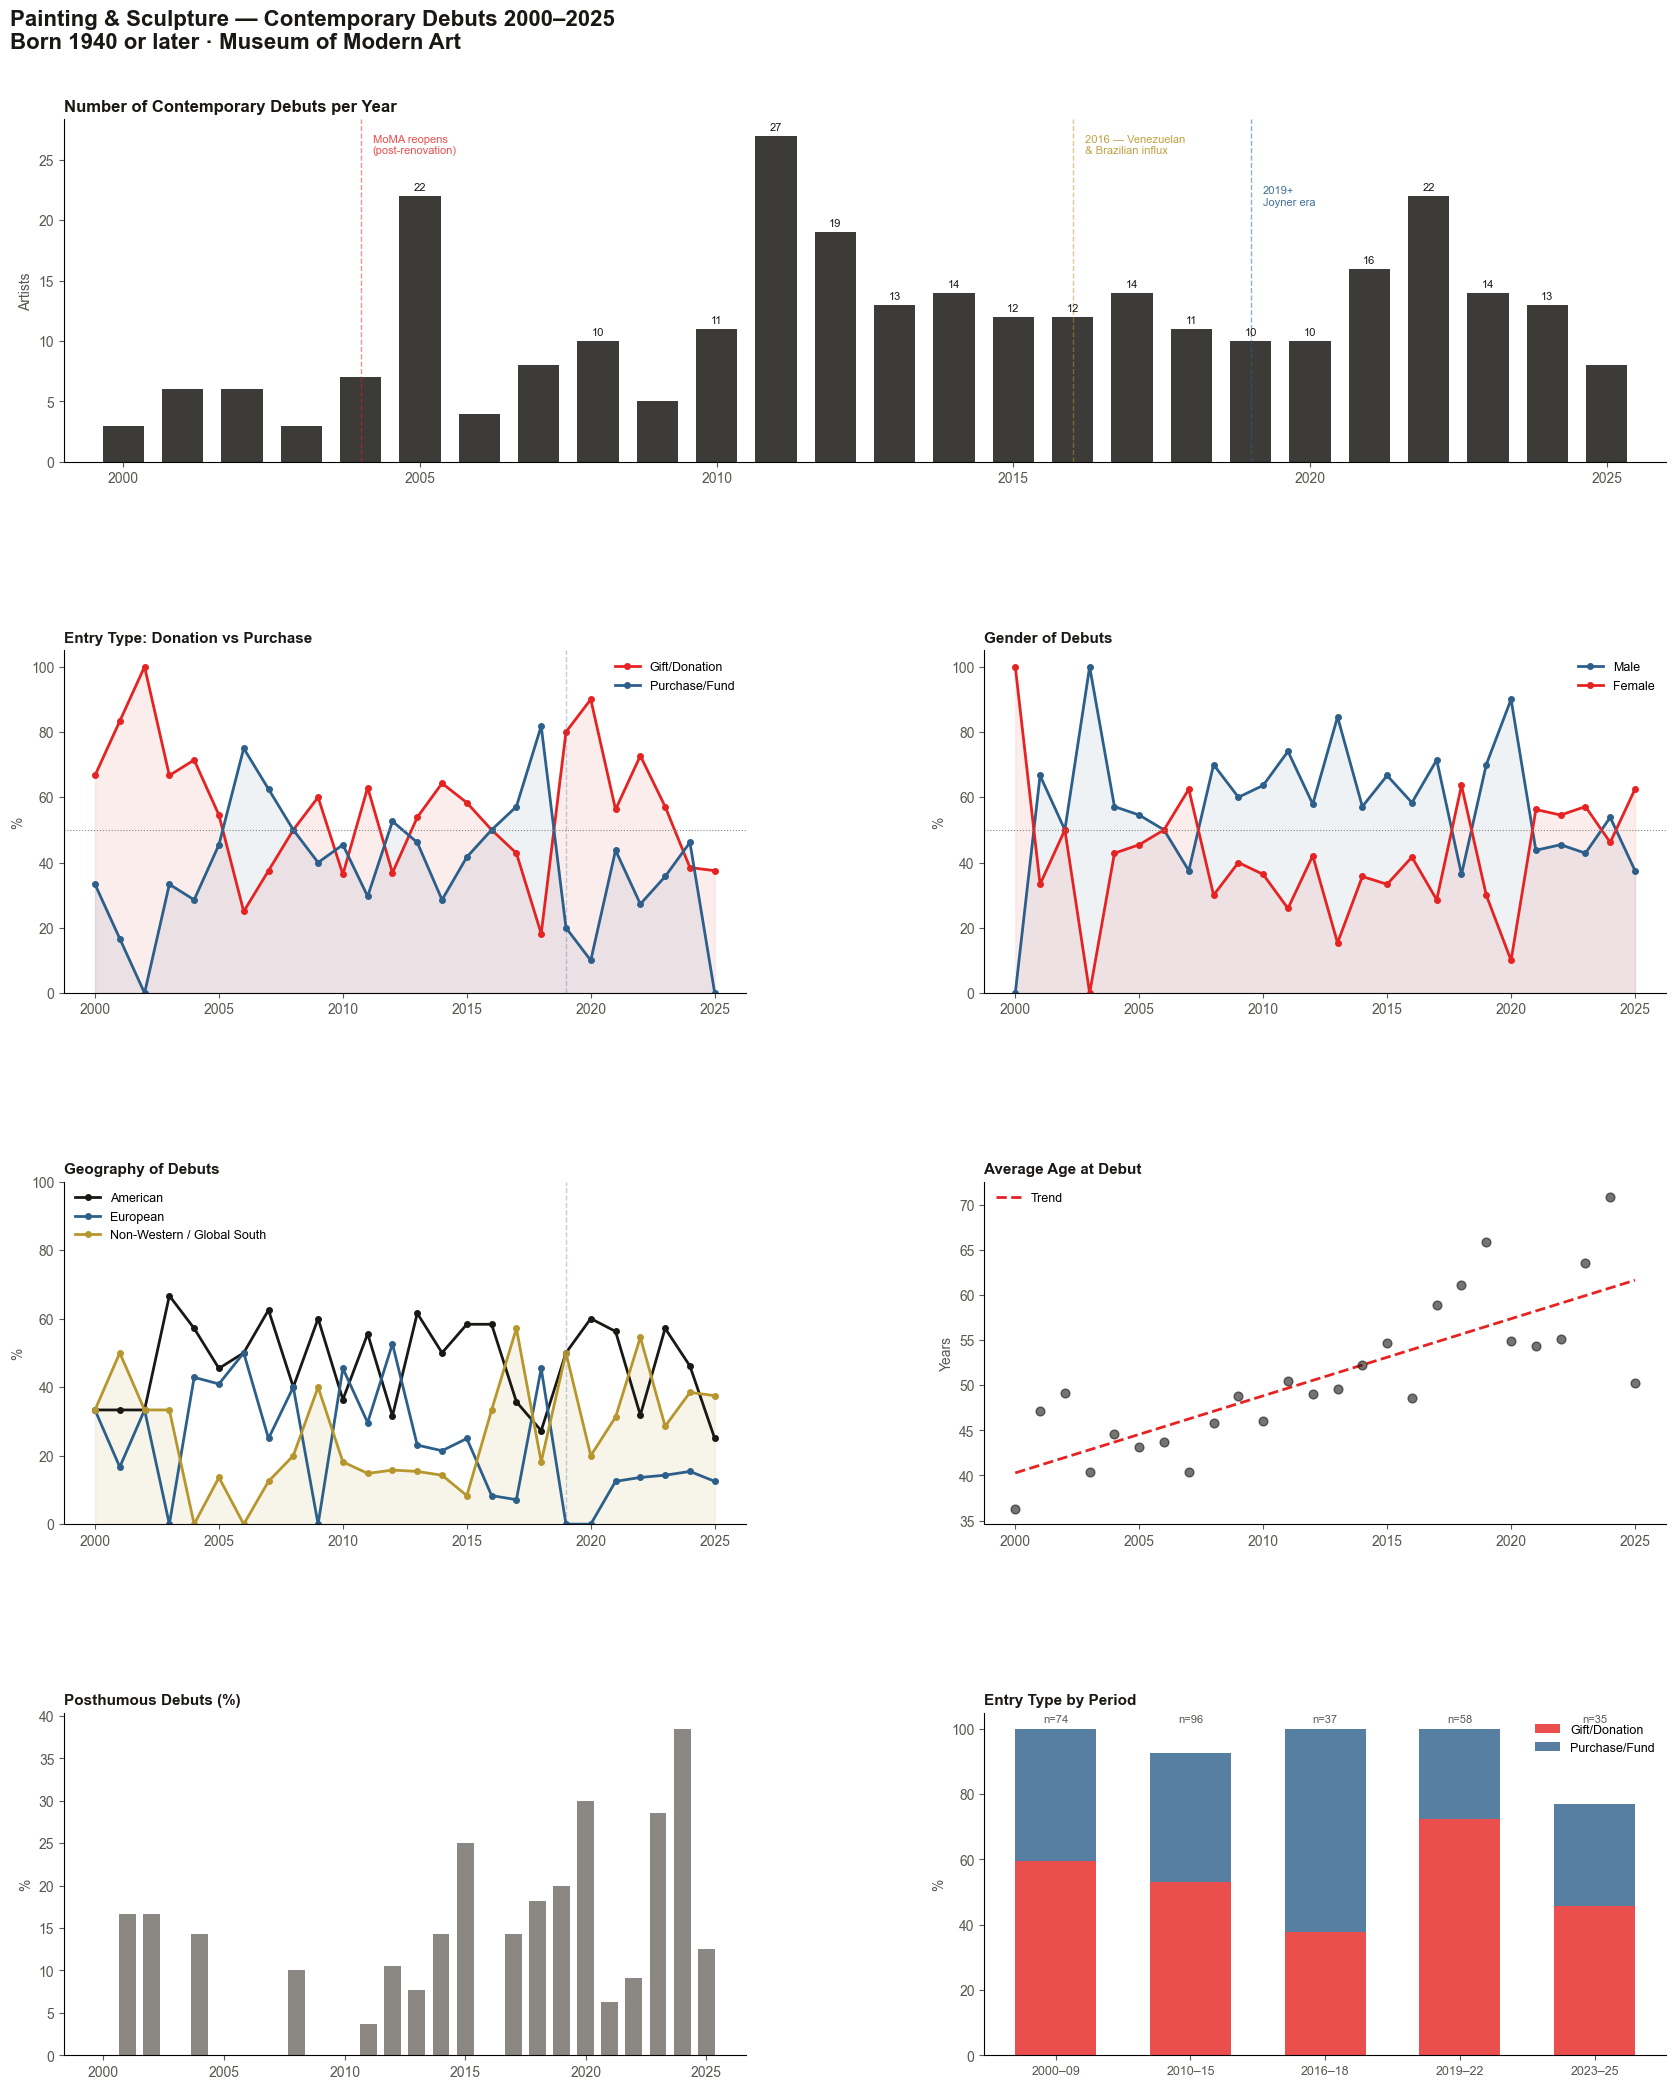

Saved: ps_debuts_2000_2025.png


In [41]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec

RED   = '#E52322'
DARK  = '#1A1814'
MID   = '#5A5650'
LIGHT = '#8A8680'
GOLD  = '#B8962E'
BLUE  = '#2C5F8A'
GREEN = '#1E7B42'
PALE  = '#F5F3EE'

fig = plt.figure(figsize=(18, 22), facecolor='white')
fig.suptitle(
    'Painting & Sculpture — Contemporary Debuts 2000–2025\nBorn 1940 or later · Museum of Modern Art',
    fontsize=16, fontweight='bold', color=DARK, y=0.98, x=0.05,
    horizontalalignment='left'
)

gs = GridSpec(4, 2, figure=fig, hspace=0.55, wspace=0.35,
              top=0.93, bottom=0.05, left=0.08, right=0.97)

years = by_year['first_year'].values

# ── 1. Number of debuts per year ──────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
bars = ax1.bar(years, by_year['n'], color=DARK, alpha=0.85, width=0.7)
ax1.set_title('Number of Contemporary Debuts per Year', fontsize=12,
              fontweight='bold', color=DARK, loc='left')
ax1.set_ylabel('Artists', color=MID, fontsize=10)
ax1.tick_params(colors=MID)
ax1.set_xlim(1999, 2026)
for bar, val in zip(bars, by_year['n']):
    if val >= 10:
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 str(int(val)), ha='center', va='bottom', fontsize=8, color=DARK)
# Annotations
ax1.axvline(2004, color=RED, linestyle='--', alpha=0.5, linewidth=1)
ax1.text(2004.2, ax1.get_ylim()[1]*0.9, 'MoMA reopens\n(post-renovation)',
         fontsize=8, color=RED, alpha=0.8)
ax1.axvline(2016, color=GOLD, linestyle='--', alpha=0.5, linewidth=1)
ax1.text(2016.2, ax1.get_ylim()[1]*0.9, '2016 — Venezuelan\n& Brazilian influx',
         fontsize=8, color=GOLD, alpha=0.9)
ax1.axvline(2019, color=BLUE, linestyle='--', alpha=0.5, linewidth=1)
ax1.text(2019.2, ax1.get_ylim()[1]*0.75, '2019+\nJoyner era',
         fontsize=8, color=BLUE, alpha=0.9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_facecolor('white')

# ── 2. Entry type over time ────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(years, by_year['pct_donation'], color=RED, linewidth=2,
         label='Gift/Donation', marker='o', markersize=4)
ax2.plot(years, by_year['pct_purchase'], color=BLUE, linewidth=2,
         label='Purchase/Fund', marker='o', markersize=4)
ax2.fill_between(years, by_year['pct_donation'], alpha=0.08, color=RED)
ax2.fill_between(years, by_year['pct_purchase'], alpha=0.08, color=BLUE)
ax2.set_title('Entry Type: Donation vs Purchase', fontsize=11,
              fontweight='bold', color=DARK, loc='left')
ax2.set_ylabel('%', color=MID, fontsize=10)
ax2.legend(fontsize=9, frameon=False)
ax2.set_ylim(0, 105)
ax2.axhline(50, color=LIGHT, linestyle=':', linewidth=0.8)
ax2.axvline(2019, color=BLUE, linestyle='--', alpha=0.3, linewidth=1)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.tick_params(colors=MID)
ax2.set_facecolor('white')

# ── 3. Gender over time ───────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(years, by_year['pct_male'],   color=BLUE,  linewidth=2,
         label='Male',   marker='o', markersize=4)
ax3.plot(years, by_year['pct_female'], color=RED,   linewidth=2,
         label='Female', marker='o', markersize=4)
ax3.fill_between(years, by_year['pct_male'],   alpha=0.08, color=BLUE)
ax3.fill_between(years, by_year['pct_female'], alpha=0.08, color=RED)
ax3.set_title('Gender of Debuts', fontsize=11,
              fontweight='bold', color=DARK, loc='left')
ax3.set_ylabel('%', color=MID, fontsize=10)
ax3.legend(fontsize=9, frameon=False)
ax3.set_ylim(0, 105)
ax3.axhline(50, color=LIGHT, linestyle=':', linewidth=0.8)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.tick_params(colors=MID)
ax3.set_facecolor('white')

# ── 4. Geography over time ────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(years, by_year['pct_american'], color=DARK,  linewidth=2,
         label='American', marker='o', markersize=4)
ax4.plot(years, by_year['pct_european'], color=BLUE,  linewidth=2,
         label='European', marker='o', markersize=4)
ax4.plot(years, by_year['pct_nonwest'],  color=GOLD,  linewidth=2,
         label='Non-Western / Global South', marker='o', markersize=4)
ax4.fill_between(years, by_year['pct_nonwest'], alpha=0.1, color=GOLD)
ax4.set_title('Geography of Debuts', fontsize=11,
              fontweight='bold', color=DARK, loc='left')
ax4.set_ylabel('%', color=MID, fontsize=10)
ax4.legend(fontsize=9, frameon=False)
ax4.set_ylim(0, 100)
ax4.axvline(2019, color=BLUE, linestyle='--', alpha=0.3, linewidth=1)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.tick_params(colors=MID)
ax4.set_facecolor('white')

# ── 5. Age at debut ───────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
# Rolling average
by_year_valid = by_year[by_year['avg_age'].notna()]
ax5.scatter(by_year_valid['first_year'], by_year_valid['avg_age'],
            color=DARK, alpha=0.6, s=40, zorder=3)
# Trend line
from numpy.polynomial.polynomial import polyfit
x = by_year_valid['first_year'].values
y = by_year_valid['avg_age'].values
coeffs = polyfit(x, y, 1)
trend = coeffs[0] + coeffs[1]*x
ax5.plot(x, trend, color=RED, linewidth=2, linestyle='--', label='Trend')
ax5.set_title('Average Age at Debut', fontsize=11,
              fontweight='bold', color=DARK, loc='left')
ax5.set_ylabel('Years', color=MID, fontsize=10)
ax5.legend(fontsize=9, frameon=False)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.tick_params(colors=MID)
ax5.set_facecolor('white')

# ── 6. Posthumous over time ───────────────────────────────────
ax6 = fig.add_subplot(gs[3, 0])
ax6.bar(years, by_year['pct_posthumous'], color=MID, alpha=0.7, width=0.7)
ax6.set_title('Posthumous Debuts (%)', fontsize=11,
              fontweight='bold', color=DARK, loc='left')
ax6.set_ylabel('%', color=MID, fontsize=10)
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)
ax6.tick_params(colors=MID)
ax6.set_facecolor('white')

# ── 7. Sub-period summary stacked bar ─────────────────────────
ax7 = fig.add_subplot(gs[3, 1])
period_labels = ['2000–09','2010–15','2016–18','2019–22','2023–25']
n_vals   = [74, 96, 37, 58, 35]
don_vals = [59.5, 53.1, 37.8, 72.4, 45.7]
pur_vals = [40.5, 39.6, 62.2, 27.6, 31.4]

x_pos = range(len(period_labels))
ax7.bar(x_pos, don_vals, color=RED, alpha=0.8, label='Gift/Donation', width=0.6)
ax7.bar(x_pos, pur_vals, bottom=don_vals, color=BLUE, alpha=0.8,
        label='Purchase/Fund', width=0.6)
ax7.set_xticks(x_pos)
ax7.set_xticklabels(period_labels, fontsize=9)
ax7.set_title('Entry Type by Period', fontsize=11,
              fontweight='bold', color=DARK, loc='left')
ax7.set_ylabel('%', color=MID, fontsize=10)
ax7.legend(fontsize=9, frameon=False)
for i, (n, d) in enumerate(zip(n_vals, don_vals)):
    ax7.text(i, 102, f'n={n}', ha='center', fontsize=8, color=MID)
ax7.spines['top'].set_visible(False)
ax7.spines['right'].set_visible(False)
ax7.tick_params(colors=MID)
ax7.set_facecolor('white')

plt.savefig('/Users/arousell/data/ps_debuts_2000_2025.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: ps_debuts_2000_2025.png")

In [42]:
# ═══════════════════════════════════════════════════════════════
# WHO ARE THEY AND HOW DID THEY GET THERE
# Full cross-analysis of 300 contemporary P&S debuts 2000-2025
# ═══════════════════════════════════════════════════════════════

print("=" * 70)
print("300 CONTEMPORARY P&S DEBUTS — FULL CROSS-ANALYSIS")
print("Born >= 1940 | Debut 2000–2025 | MoMA Painting & Sculpture")
print("=" * 70)

# ── 1. WHO: complete artist list by period ─────────────────────
for period_label, y1, y2 in [
    ("2000–2009", 2000, 2009),
    ("2010–2018", 2010, 2018),
    ("2019–2025", 2019, 2025),
]:
    grp = focus[focus['first_year'].between(y1, y2)].sort_values('first_year')
    print(f"\n\n── {period_label} ({len(grp)} artists) ────────────────────────────────")
    print(f"{'Artist':<35} {'Year':>5} {'Born':>6} {'Died':>7} "
          f"{'Nat':>12} {'Gender':>8} {'Entry'}")
    print("-" * 88)
    for _, r in grp.iterrows():
        died = f"{r['death_year']:.0f}" if pd.notna(r['death_year']) else "living"
        born = f"{r['birth_year']:.0f}" if pd.notna(r['birth_year']) else "?"
        print(f"  {r['Artist']:<33} {r['first_year']:>5} "
              f"{born:>6} {died:>7} "
              f"{r['nationality']:>12} {r['gender']:>8}  {r['entry_type']}")

# ── 2. HOW: entry type breakdown ──────────────────────────────
print("\n\n" + "=" * 70)
print("HOW THEY GOT THERE — ENTRY TYPE BY PERIOD")
print("=" * 70)

for period_label, y1, y2 in [
    ("2000–2009", 2000, 2009),
    ("2010–2018", 2010, 2018),
    ("2019–2025", 2019, 2025),
]:
    grp = focus[focus['first_year'].between(y1, y2)]
    n = len(grp)
    print(f"\n  {period_label} (n={n}):")
    for k, v in grp['entry_type'].value_counts().items():
        bar = '▪' * int(v/n*40)
        print(f"    {k:<22} {v:>4}  ({v/n*100:>5.1f}%)  {bar}")

# ── 3. CROSS: entry type × gender ─────────────────────────────
print("\n\n" + "=" * 70)
print("CROSS: ENTRY TYPE × GENDER (2000–2025)")
print("=" * 70)
ct_gender = pd.crosstab(
    focus['entry_type'], focus['gender'],
    margins=True, normalize='index'
) * 100
print(ct_gender.round(1).to_string())

# ── 4. CROSS: entry type × geography ──────────────────────────
print("\n\n" + "=" * 70)
print("CROSS: ENTRY TYPE × GEOGRAPHY (2000–2025)")
print("=" * 70)
ct_geo = pd.crosstab(
    focus['entry_type'], focus['geo'],
    margins=True, normalize='index'
) * 100
print(ct_geo.round(1).to_string())

# ── 5. CROSS: entry type × gender × period ────────────────────
print("\n\n" + "=" * 70)
print("CROSS: DONATION vs PURCHASE — WHO GETS EACH ROUTE")
print("=" * 70)

donation  = focus[focus['entry_type'] == 'Gift/Donation']
purchase  = focus[focus['entry_type'] == 'Purchase/Fund']

for route_label, grp in [("GIFT/DONATION", donation), ("PURCHASE/FUND", purchase)]:
    n = len(grp)
    print(f"\n  {route_label} (n={n}):")
    print(f"    Gender:")
    for k, v in grp['gender'].value_counts().items():
        print(f"      {k:<12} {v:>4}  ({v/n*100:.1f}%)")
    print(f"    Geography:")
    for k, v in grp['geo'].value_counts().items():
        print(f"      {k:<30} {v:>4}  ({v/n*100:.1f}%)")
    print(f"    Posthumous: {grp['is_posthumous'].sum()} ({grp['is_posthumous'].mean()*100:.1f}%)")
    print(f"    Avg age at debut: {grp['age_at_debut_clean'].mean():.1f}")
    print(f"    Top nationalities:")
    for k, v in grp['nationality'].value_counts().head(6).items():
        print(f"      {k:<18} {v:>4}  ({v/n*100:.1f}%)")

# ── 6. SHIFT: what changed 2000-2018 vs 2019-2025 ─────────────
print("\n\n" + "=" * 70)
print("THE SHIFT: 2000–2018 vs 2019–2025")
print("=" * 70)

pre  = focus[focus['first_year'] <= 2018]
post = focus[focus['first_year'] >= 2019]

metrics = [
    ("Gift/Donation %",    
     (pre['entry_type']=='Gift/Donation').mean()*100,
     (post['entry_type']=='Gift/Donation').mean()*100),
    ("Purchase/Fund %",    
     (pre['entry_type']=='Purchase/Fund').mean()*100,
     (post['entry_type']=='Purchase/Fund').mean()*100),
    ("Female %",           
     (pre['gender']=='Female').mean()*100,
     (post['gender']=='Female').mean()*100),
    ("Male %",             
     (pre['gender']=='Male').mean()*100,
     (post['gender']=='Male').mean()*100),
    ("American %",         
     (pre['geo']=='American').mean()*100,
     (post['geo']=='American').mean()*100),
    ("European %",         
     (pre['geo']=='European').mean()*100,
     (post['geo']=='European').mean()*100),
    ("Non-Western %",      
     (pre['geo']=='Non-Western / Global South').mean()*100,
     (post['geo']=='Non-Western / Global South').mean()*100),
    ("Posthumous %",       
     pre['is_posthumous'].mean()*100,
     post['is_posthumous'].mean()*100),
    ("Avg age at debut",   
     pre['age_at_debut_clean'].mean(),
     post['age_at_debut_clean'].mean()),
]

print(f"\n  {'Metric':<25} {'2000–2018':>12} {'2019–2025':>12} {'Change':>10}")
print("  " + "-" * 62)
for label, v_pre, v_post in metrics:
    delta = v_post - v_pre
    arrow = "▲" if delta > 0 else "▼"
    print(f"  {label:<25} {v_pre:>11.1f}  {v_post:>11.1f}  "
          f"{arrow} {abs(delta):>6.1f}")

print(f"\n  n (2000–2018): {len(pre)}")
print(f"  n (2019–2025): {len(post)}")

300 CONTEMPORARY P&S DEBUTS — FULL CROSS-ANALYSIS
Born >= 1940 | Debut 2000–2025 | MoMA Painting & Sculpture


── 2000–2009 (74 artists) ────────────────────────────────
Artist                               Year   Born    Died          Nat   Gender Entry
----------------------------------------------------------------------------------------
  Elizabeth Peyton                   2000   1965  living     American   Female  Gift/Donation
  Pipilotti Rist                     2000   1962  living        Swiss   Female  Gift/Donation
  Janine Antoni                      2000   1964  living     Bahamian   Female  Purchase/Fund
  José Leonilson                     2001   1957    1993    Brazilian     Male  Gift/Donation
  Billy Sullivan                     2001   1946  living     American     Male  Gift/Donation
  Shirazeh Houshiary                 2001   1955  living      British   Female  Purchase/Fund
  Polly Apfelbaum                    2001   1955  living     American   Female  Gift/Donatio

In [45]:
import json

# Load exhibitions data
with open('/Users/arousell/data/scraped/exhibitions_raw.json', 'r') as f:
    exhibitions = json.load(f)

print(f"Total exhibitions: {len(exhibitions)}")
print(f"\nSample record (first exhibition):")
print(json.dumps(exhibitions[0], indent=2)[:1000])
print("\n...")
print(f"\nKeys in exhibition records:")
print(list(exhibitions[0].keys()))

# Check date range
dates = [e.get('date', e.get('year', e.get('Date', ''))) for e in exhibitions]
dates_clean = [d for d in dates if d]
print(f"\nDate field examples (first 10):")
for d in dates_clean[:10]:
    print(f"  {d}")

Total exhibitions: 3217

Sample record (first exhibition):
{
  "id": 1700,
  "title": "Five Recent Acquisitions",
  "date": "Apr\u00a018\u2013Jun\u00a022, 1975",
  "description": "We use our own and third-party cookies to personalize your experience and the promotions you see.",
  "artists": [
    {
      "id": "5053",
      "name": "Georges Rouault"
    },
    {
      "id": "3832",
      "name": "Henri Matisse"
    },
    {
      "id": "665",
      "name": "Pierre Bonnard"
    },
    {
      "id": "4164",
      "name": "Edvard Munch"
    },
    {
      "id": "3408",
      "name": "Marie Laurencin"
    }
  ],
  "artist_count": 5
}

...

Keys in exhibition records:
['id', 'title', 'date', 'description', 'artists', 'artist_count']

Date field examples (first 10):
  Apr 18–Jun 22, 1975
  Mar 15–Apr 24, 1979
  Dec 22, 1980–Mar 10, 1981
  Oct 21, 1941–Apr 30, 1944
  Jan 7–Feb 22, 1972
  Aug 18–Oct 21, 1981
  Feb 21–Jun 4, 1985
  May 17–Oct 6, 1931
  Jun 7–Oct 30, 1932
  Jul 10–Sep 30, 1933


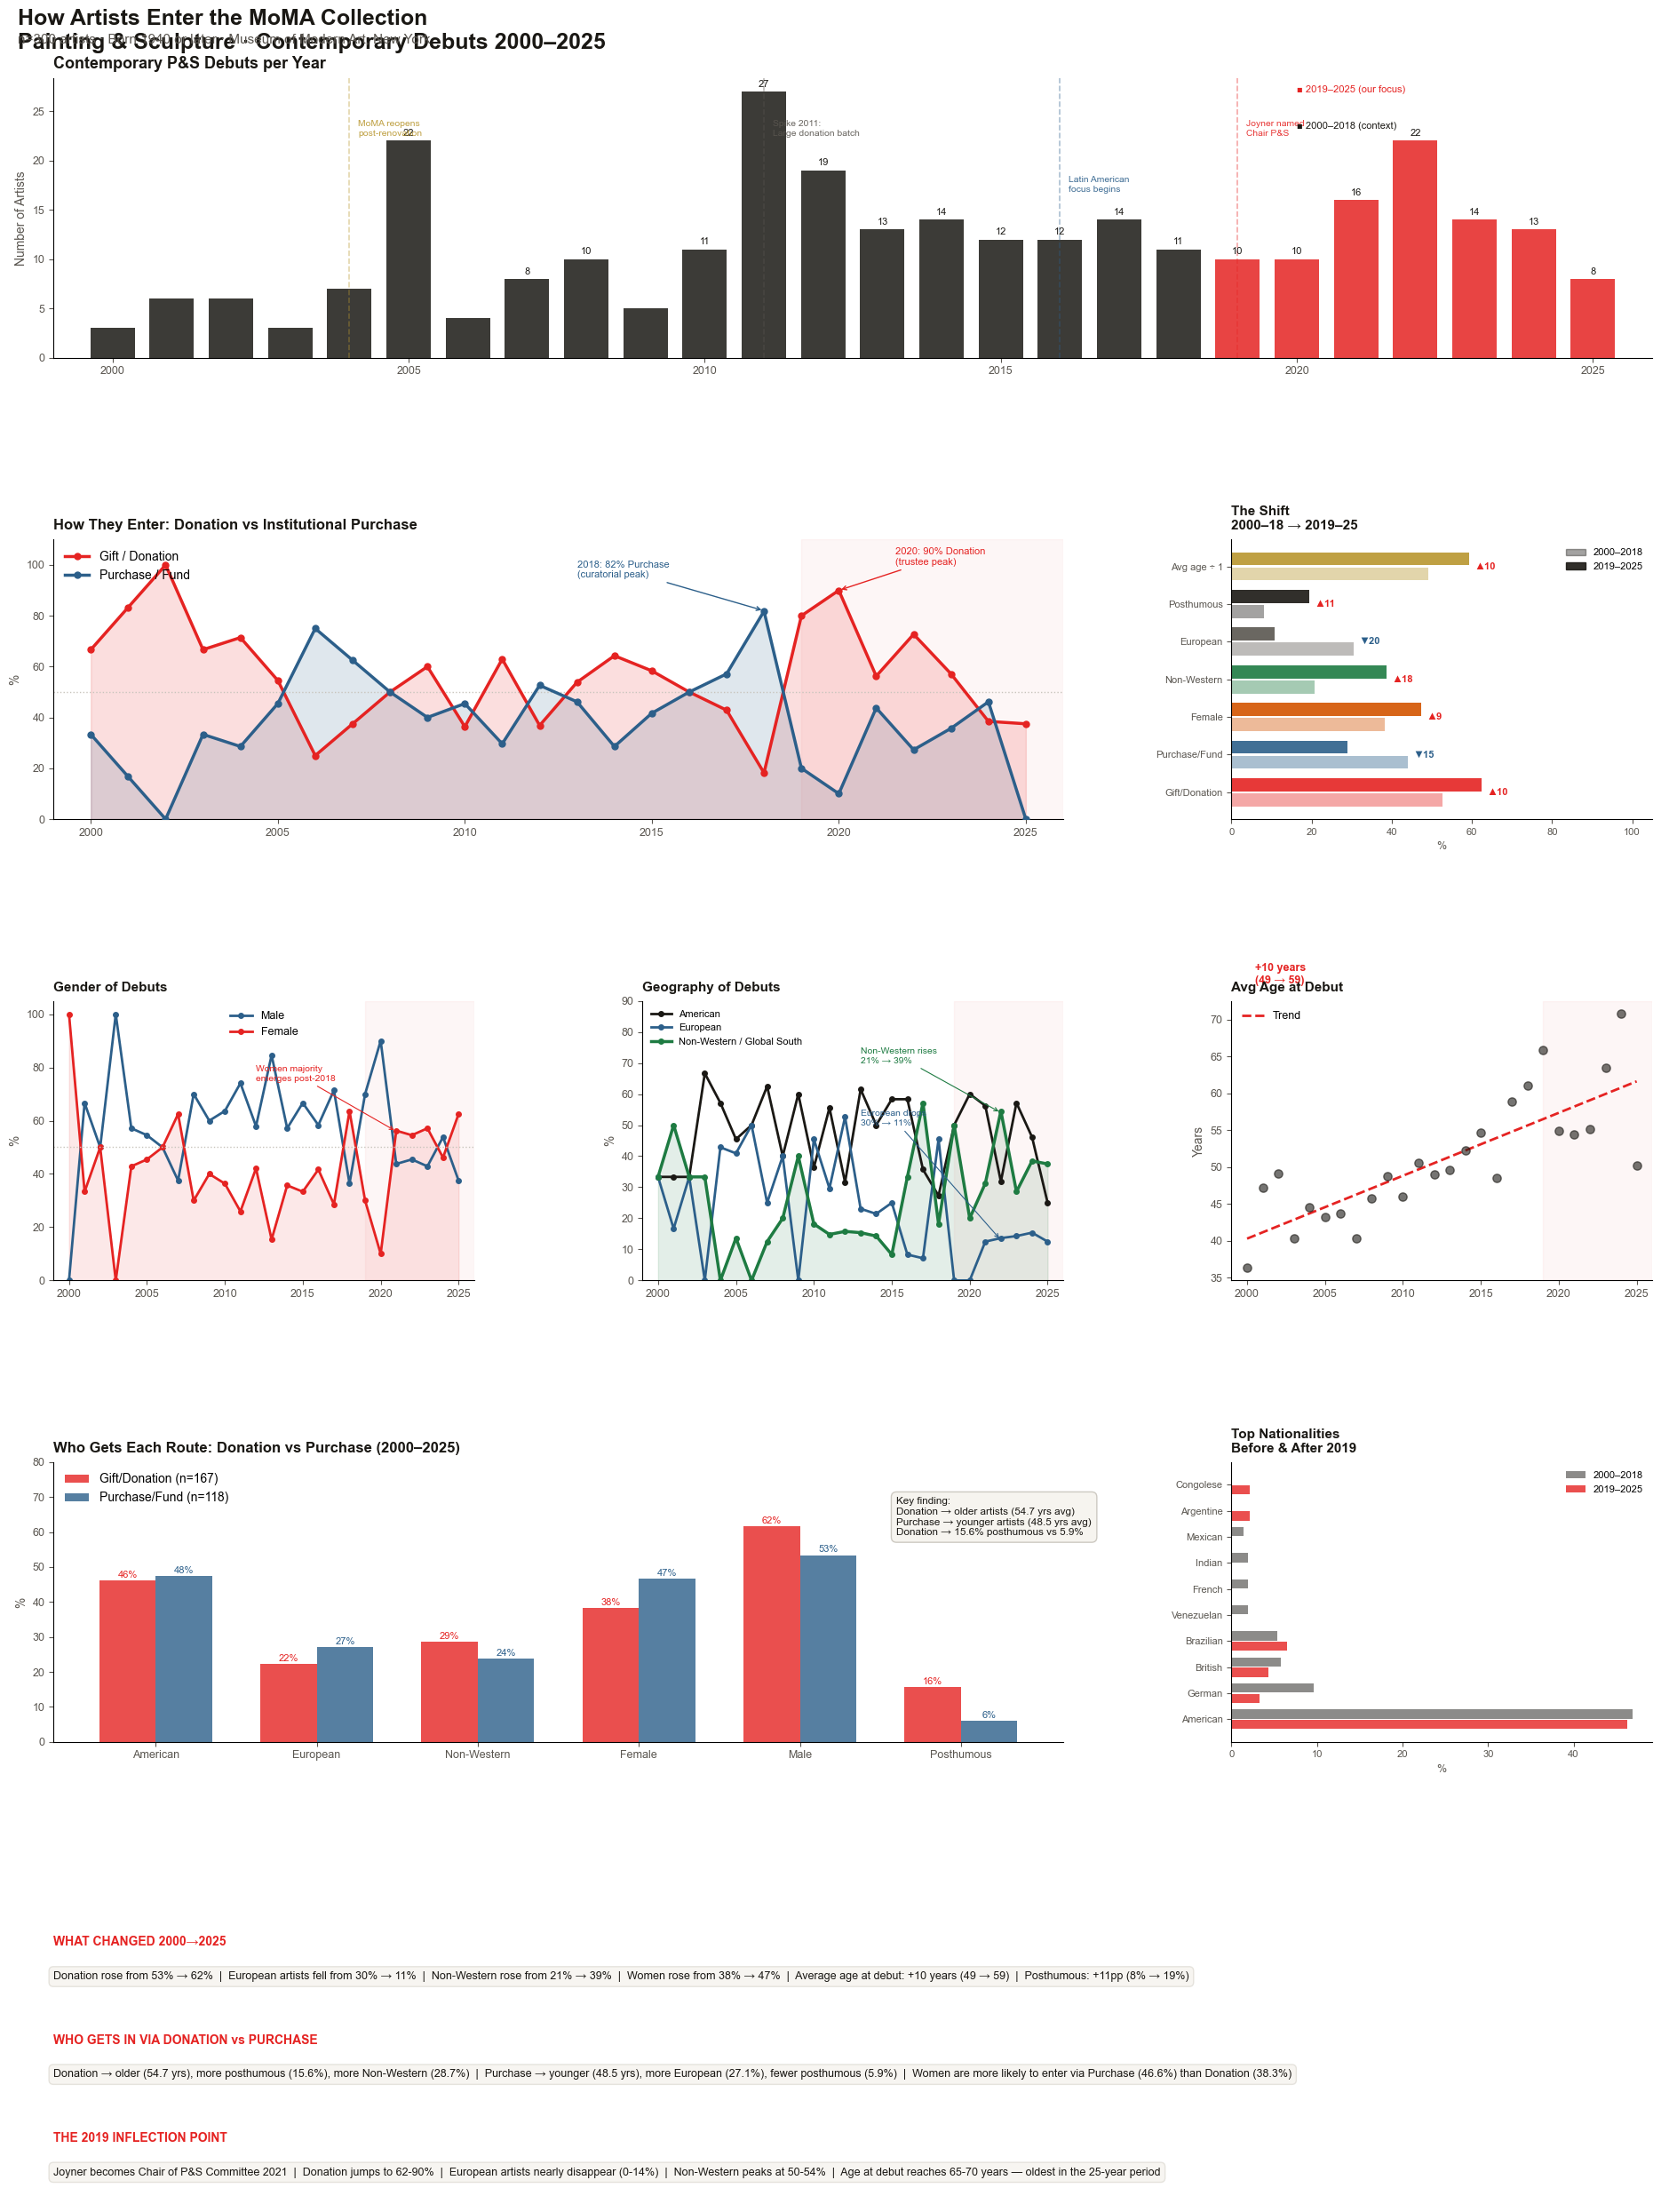

Saved: ps_how_they_got_there.png


In [44]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import numpy as np

RED   = '#E52322'
DARK  = '#1A1814'
MID   = '#5A5650'
LIGHT = '#C8C4BC'
GOLD  = '#B8962E'
BLUE  = '#2C5F8A'
GREEN = '#1E7B42'
ORANGE = '#D35400'

fig = plt.figure(figsize=(20, 26), facecolor='white')
fig.suptitle(
    'How Artists Enter the MoMA Collection\nPainting & Sculpture · Contemporary Debuts 2000–2025',
    fontsize=18, fontweight='bold', color=DARK,
    y=0.99, x=0.05, ha='left'
)
fig.text(0.05, 0.975, 'n=300 artists · Born 1940 or later · Museum of Modern Art, New York',
         fontsize=11, color=MID, ha='left')

gs = GridSpec(5, 3, figure=fig,
              hspace=0.65, wspace=0.4,
              top=0.96, bottom=0.04,
              left=0.07, right=0.97)

years = by_year['first_year'].values

# ── 1. DEBUTS PER YEAR (full width) ───────────────────────────
ax1 = fig.add_subplot(gs[0, :])
colors_bar = [RED if y >= 2019 else DARK for y in years]
bars = ax1.bar(years, by_year['n'], color=colors_bar, alpha=0.85, width=0.75)
ax1.set_title('Contemporary P&S Debuts per Year',
              fontsize=13, fontweight='bold', color=DARK, loc='left', pad=8)
ax1.set_ylabel('Number of Artists', color=MID, fontsize=10)
ax1.set_xlim(1999, 2026)
ax1.tick_params(colors=MID, labelsize=9)

for bar, val in zip(bars, by_year['n']):
    if val >= 8:
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 str(int(val)), ha='center', va='bottom', fontsize=8, color=DARK)

# Key annotations
for x, label, color, yoff in [
    (2004, 'MoMA reopens\npost-renovation', GOLD, 0.85),
    (2011, 'Spike 2011:\nLarge donation batch', MID, 0.85),
    (2016, 'Latin American\nfocus begins', BLUE, 0.65),
    (2019, 'Joyner named\nChair P&S', RED, 0.85),
]:
    ax1.axvline(x, color=color, linestyle='--', alpha=0.4, linewidth=1.2)
    ax1.text(x+0.15, ax1.get_ylim()[1]*yoff, label,
             fontsize=7.5, color=color, alpha=0.9, va='top')

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_facecolor('white')

# Legend for bar colors
ax1.text(2020, ax1.get_ylim()[1]*0.95, '■ 2019–2025 (our focus)',
         fontsize=8, color=RED)
ax1.text(2020, ax1.get_ylim()[1]*0.82, '■ 2000–2018 (context)',
         fontsize=8, color=DARK)

# ── 2. ENTRY TYPE OVER TIME ────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :2])
ax2.fill_between(years, by_year['pct_donation'],
                 alpha=0.15, color=RED)
ax2.fill_between(years, by_year['pct_purchase'],
                 alpha=0.15, color=BLUE)
ax2.plot(years, by_year['pct_donation'], color=RED, linewidth=2.5,
         label='Gift / Donation', marker='o', markersize=5, zorder=3)
ax2.plot(years, by_year['pct_purchase'], color=BLUE, linewidth=2.5,
         label='Purchase / Fund', marker='o', markersize=5, zorder=3)
ax2.axhline(50, color=LIGHT, linestyle=':', linewidth=1)
ax2.axvspan(2019, 2026, alpha=0.04, color=RED)
ax2.set_title('How They Enter: Donation vs Institutional Purchase',
              fontsize=12, fontweight='bold', color=DARK, loc='left', pad=8)
ax2.set_ylabel('%', color=MID, fontsize=10)
ax2.set_ylim(0, 110)
ax2.set_xlim(1999, 2026)
ax2.legend(fontsize=10, frameon=False, loc='upper left')
ax2.tick_params(colors=MID, labelsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_facecolor('white')

# Annotate 2018 surge
ax2.annotate('2018: 82% Purchase\n(curatorial peak)',
             xy=(2018, 82), xytext=(2013, 95),
             fontsize=8, color=BLUE,
             arrowprops=dict(arrowstyle='->', color=BLUE, lw=1))
ax2.annotate('2020: 90% Donation\n(trustee peak)',
             xy=(2020, 90), xytext=(2021.5, 100),
             fontsize=8, color=RED,
             arrowprops=dict(arrowstyle='->', color=RED, lw=1))

# ── 3. THE SHIFT — compact summary ────────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
metrics_shift = [
    ('Gift/Donation', 52.7, 62.4, RED),
    ('Purchase/Fund', 44.0, 29.0, BLUE),
    ('Female',        38.2, 47.3, ORANGE),
    ('Non-Western',   20.8, 38.7, GREEN),
    ('European',      30.4, 10.8, MID),
    ('Posthumous',     8.2, 19.4, DARK),
    ('Avg age ÷ 1',  49.2, 59.2, GOLD),
]
y_pos = range(len(metrics_shift))
ax3.set_title('The Shift\n2000–18 → 2019–25',
              fontsize=11, fontweight='bold', color=DARK, loc='left', pad=8)
for i, (label, v_pre, v_post, col) in enumerate(metrics_shift):
    ax3.barh(i-0.2, v_pre,  height=0.35, color=col, alpha=0.4)
    ax3.barh(i+0.2, v_post, height=0.35, color=col, alpha=0.9)
    delta = v_post - v_pre
    arrow = '▲' if delta > 0 else '▼'
    col_d = RED if delta > 0 else BLUE
    ax3.text(max(v_pre, v_post)+1.5, i,
             f"{arrow}{abs(delta):.0f}",
             va='center', fontsize=8, color=col_d, fontweight='bold')
ax3.set_yticks(range(len(metrics_shift)))
ax3.set_yticklabels([m[0] for m in metrics_shift], fontsize=9, color=DARK)
ax3.set_xlim(0, 105)
ax3.set_xlabel('%', color=MID, fontsize=9)
ax3.tick_params(colors=MID, labelsize=8)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.set_facecolor('white')
light_patch = mpatches.Patch(alpha=0.4, color=DARK, label='2000–2018')
dark_patch  = mpatches.Patch(alpha=0.9, color=DARK, label='2019–2025')
ax3.legend(handles=[light_patch, dark_patch], fontsize=8, frameon=False)

# ── 4. GENDER OVER TIME ───────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(years, by_year['pct_male'],   color=BLUE, linewidth=2,
         label='Male', marker='o', markersize=4)
ax4.plot(years, by_year['pct_female'], color=RED,  linewidth=2,
         label='Female', marker='o', markersize=4)
ax4.fill_between(years, by_year['pct_female'], alpha=0.1, color=RED)
ax4.axhline(50, color=LIGHT, linestyle=':', linewidth=1)
ax4.axvspan(2019, 2026, alpha=0.04, color=RED)
ax4.set_title('Gender of Debuts',
              fontsize=11, fontweight='bold', color=DARK, loc='left', pad=8)
ax4.set_ylabel('%', color=MID, fontsize=10)
ax4.set_ylim(0, 105)
ax4.set_xlim(1999, 2026)
ax4.legend(fontsize=9, frameon=False)
ax4.tick_params(colors=MID, labelsize=9)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.set_facecolor('white')
ax4.annotate('Women majority\nemerges post-2018',
             xy=(2021, 56), xytext=(2012, 75),
             fontsize=7.5, color=RED,
             arrowprops=dict(arrowstyle='->', color=RED, lw=0.8))

# ── 5. GEOGRAPHY OVER TIME ────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
ax5.plot(years, by_year['pct_american'], color=DARK,  linewidth=2,
         label='American', marker='o', markersize=4)
ax5.plot(years, by_year['pct_european'], color=BLUE,  linewidth=2,
         label='European', marker='o', markersize=4)
ax5.plot(years, by_year['pct_nonwest'],  color=GREEN, linewidth=2.5,
         label='Non-Western / Global South', marker='o', markersize=4)
ax5.fill_between(years, by_year['pct_nonwest'], alpha=0.12, color=GREEN)
ax5.axvspan(2019, 2026, alpha=0.04, color=RED)
ax5.set_title('Geography of Debuts',
              fontsize=11, fontweight='bold', color=DARK, loc='left', pad=8)
ax5.set_ylabel('%', color=MID, fontsize=10)
ax5.set_ylim(0, 90)
ax5.set_xlim(1999, 2026)
ax5.legend(fontsize=8, frameon=False)
ax5.tick_params(colors=MID, labelsize=9)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.set_facecolor('white')
ax5.annotate('European drops\n30% → 11%',
             xy=(2022, 13), xytext=(2013, 50),
             fontsize=7.5, color=BLUE,
             arrowprops=dict(arrowstyle='->', color=BLUE, lw=0.8))
ax5.annotate('Non-Western rises\n21% → 39%',
             xy=(2022, 54), xytext=(2013, 70),
             fontsize=7.5, color=GREEN,
             arrowprops=dict(arrowstyle='->', color=GREEN, lw=0.8))

# ── 6. AGE AT DEBUT ───────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
valid = by_year[by_year['avg_age'].notna()]
ax6.scatter(valid['first_year'], valid['avg_age'],
            color=DARK, alpha=0.6, s=45, zorder=3)
x = valid['first_year'].values
y = valid['avg_age'].values
from numpy.polynomial.polynomial import polyfit
c = polyfit(x, y, 1)
ax6.plot(x, c[0]+c[1]*x, color=RED, linewidth=2, linestyle='--', label='Trend')
ax6.axvspan(2019, 2026, alpha=0.04, color=RED)
ax6.set_title('Avg Age at Debut',
              fontsize=11, fontweight='bold', color=DARK, loc='left', pad=8)
ax6.set_ylabel('Years', color=MID, fontsize=10)
ax6.set_xlim(1999, 2026)
ax6.legend(fontsize=9, frameon=False)
ax6.tick_params(colors=MID, labelsize=9)
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)
ax6.set_facecolor('white')
ax6.text(2000.5, 75, '+10 years\n(49 → 59)', fontsize=9,
         color=RED, fontweight='bold')

# ── 7. DONATION vs PURCHASE: WHO GETS EACH ROUTE ──────────────
ax7 = fig.add_subplot(gs[3, :2])
categories = ['American', 'European', 'Non-Western', 'Female', 'Male', 'Posthumous']
don_vals = [46.1, 22.2, 28.7, 38.3, 61.7, 15.6]
pur_vals = [47.5, 27.1, 23.7, 46.6, 53.4,  5.9]

x_pos = np.arange(len(categories))
width = 0.35
b1 = ax7.bar(x_pos - width/2, don_vals, width, color=RED, alpha=0.8, label='Gift/Donation (n=167)')
b2 = ax7.bar(x_pos + width/2, pur_vals, width, color=BLUE, alpha=0.8, label='Purchase/Fund (n=118)')

ax7.set_title('Who Gets Each Route: Donation vs Purchase (2000–2025)',
              fontsize=12, fontweight='bold', color=DARK, loc='left', pad=8)
ax7.set_ylabel('%', color=MID, fontsize=10)
ax7.set_xticks(x_pos)
ax7.set_xticklabels(categories, fontsize=10)
ax7.legend(fontsize=10, frameon=False)
ax7.set_ylim(0, 80)
ax7.tick_params(colors=MID, labelsize=9)
ax7.spines['top'].set_visible(False)
ax7.spines['right'].set_visible(False)
ax7.set_facecolor('white')

# Add value labels
for bar in b1:
    ax7.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
             f"{bar.get_height():.0f}%", ha='center', fontsize=8, color=RED)
for bar in b2:
    ax7.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
             f"{bar.get_height():.0f}%", ha='center', fontsize=8, color=BLUE)

# Key insight box
ax7.text(4.6, 70,
         'Key finding:\nDonation → older artists (54.7 yrs avg)\nPurchase → younger artists (48.5 yrs avg)\nDonation → 15.6% posthumous vs 5.9%',
         fontsize=8.5, color=DARK, va='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor=PALE if True else 'white',
                   edgecolor=LIGHT, alpha=0.9))

# ── 8. TOP NATIONALITIES 2000-18 vs 2019-25 ───────────────────
ax8 = fig.add_subplot(gs[3, 2])
pre_nats  = focus[focus['first_year']<=2018]['nationality'].value_counts().head(8)
post_nats = focus[focus['first_year']>=2019]['nationality'].value_counts().head(8)

all_nats = list(dict.fromkeys(list(pre_nats.index) + list(post_nats.index)))[:10]
pre_v  = [pre_nats.get(n, 0) / len(focus[focus['first_year']<=2018]) * 100 for n in all_nats]
post_v = [post_nats.get(n, 0) / len(focus[focus['first_year']>=2019]) * 100 for n in all_nats]

yp = np.arange(len(all_nats))
ax8.barh(yp+0.2, pre_v,  height=0.35, color=DARK, alpha=0.5, label='2000–2018')
ax8.barh(yp-0.2, post_v, height=0.35, color=RED,  alpha=0.8, label='2019–2025')
ax8.set_yticks(yp)
ax8.set_yticklabels(all_nats, fontsize=9)
ax8.set_title('Top Nationalities\nBefore & After 2019',
              fontsize=11, fontweight='bold', color=DARK, loc='left', pad=8)
ax8.set_xlabel('%', color=MID, fontsize=9)
ax8.legend(fontsize=8, frameon=False)
ax8.tick_params(colors=MID, labelsize=8)
ax8.spines['top'].set_visible(False)
ax8.spines['right'].set_visible(False)
ax8.set_facecolor('white')

# ── 9. KEY FINDINGS TEXT BOX ──────────────────────────────────
ax9 = fig.add_subplot(gs[4, :])
ax9.axis('off')

findings = [
    ("WHAT CHANGED 2000→2025",
     "Donation rose from 53% → 62%  |  European artists fell from 30% → 11%  |  "
     "Non-Western rose from 21% → 39%  |  Women rose from 38% → 47%  |  "
     "Average age at debut: +10 years (49 → 59)  |  Posthumous: +11pp (8% → 19%)"),

    ("WHO GETS IN VIA DONATION vs PURCHASE",
     "Donation → older (54.7 yrs), more posthumous (15.6%), more Non-Western (28.7%)  |  "
     "Purchase → younger (48.5 yrs), more European (27.1%), fewer posthumous (5.9%)  |  "
     "Women are more likely to enter via Purchase (46.6%) than Donation (38.3%)"),

    ("THE 2019 INFLECTION POINT",
     "Joyner becomes Chair of P&S Committee 2021  |  Donation jumps to 62-90%  |  "
     "European artists nearly disappear (0-14%)  |  Non-Western peaks at 50-54%  |  "
     "Age at debut reaches 65-70 years — oldest in the 25-year period"),
]

y_start = 0.92
for title, text in findings:
    ax9.text(0.0, y_start, title, fontsize=10, fontweight='bold',
             color=RED, transform=ax9.transAxes)
    ax9.text(0.0, y_start - 0.12, text, fontsize=9, color=DARK,
             transform=ax9.transAxes, wrap=True,
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#F5F3EE',
                       edgecolor='#E0DDD6', alpha=0.8))
    y_start -= 0.35

plt.savefig('/Users/arousell/data/ps_how_they_got_there.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: ps_how_they_got_there.png")

In [6]:
import json
import pandas as pd

with open('/Users/arousell/data/scraped/exhibitions_raw.json', 'r') as f:
    exhibitions_raw = json.load(f)

exh_list = []
for exh in exhibitions_raw:
    if not exh.get('artists'):
        continue
    for artist in exh['artists']:
        exh_list.append({
            'exhibition_id': exh.get('id'),
            'exhibition_title': exh.get('title'),
            'exhibition_type': exh.get('type'),
            'year': str(exh.get('begin_date', ''))[:4] if exh.get('begin_date') else str(exh.get('year', '')),
            'artist': artist
        })

exh_df = pd.DataFrame(exh_list)
print(f"Total exhibition-artist records: {len(exh_df)}")
print(f"Date range: {exh_df['year'].min()} - {exh_df['year'].max()}")
print(exh_df.head())

Total exhibition-artist records: 8291
Date range:  - 
   exhibition_id          exhibition_title exhibition_type year  \
0           1700  Five Recent Acquisitions            None        
1           1700  Five Recent Acquisitions            None        
2           1700  Five Recent Acquisitions            None        
3           1700  Five Recent Acquisitions            None        
4           1700  Five Recent Acquisitions            None        

                                      artist  
0  {'id': '5053', 'name': 'Georges Rouault'}  
1    {'id': '3832', 'name': 'Henri Matisse'}  
2    {'id': '665', 'name': 'Pierre Bonnard'}  
3     {'id': '4164', 'name': 'Edvard Munch'}  
4  {'id': '3408', 'name': 'Marie Laurencin'}  


In [46]:
import re

# ── Parse exhibition year ──────────────────────────────────────
def extract_year(date_str):
    if not date_str: return None
    years = re.findall(r'\b(19|20)\d{2}\b', str(date_str))
    return int(years[-1]) if years else None

for e in exhibitions:
    e['year_parsed'] = extract_year(e.get('date', ''))

# ── Build artist → exhibitions lookup ─────────────────────────
# Map artist name to all exhibitions they appear in
artist_exhibitions = {}
for e in exhibitions:
    yr = e['year_parsed']
    for a in e.get('artists', []):
        name = a['name']
        if name not in artist_exhibitions:
            artist_exhibitions[name] = []
        artist_exhibitions[name].append({
            'exhibition_id': e['id'],
            'title': e['title'],
            'year': yr,
        })

print(f"Artists with at least 1 exhibition in MoMA records: {len(artist_exhibitions):,}")

# ── Cross with our 300 debutants ──────────────────────────────
focus['n_exhibitions_total']  = focus['Artist'].map(
    lambda x: len(artist_exhibitions.get(x, [])))
focus['n_exhibitions_before'] = focus.apply(
    lambda r: sum(1 for e in artist_exhibitions.get(r['Artist'], [])
                  if e['year'] and e['year'] < r['first_year']), axis=1)
focus['n_exhibitions_after']  = focus.apply(
    lambda r: sum(1 for e in artist_exhibitions.get(r['Artist'], [])
                  if e['year'] and e['year'] >= r['first_year']), axis=1)
focus['had_moma_show_before'] = focus['n_exhibitions_before'] > 0

print(f"\n── EXHIBITION CROSS-REFERENCE ──────────────────────────────")
print(f"  Our 300 artists found in MoMA exhibition records:")
n_found = (focus['n_exhibitions_total'] > 0).sum()
print(f"    Any exhibition:           {n_found} ({n_found/len(focus)*100:.1f}%)")
had_before = focus['had_moma_show_before'].sum()
print(f"    Exhibition BEFORE debut:  {had_before} ({had_before/len(focus)*100:.1f}%)")
only_after = ((focus['n_exhibitions_before']==0) & (focus['n_exhibitions_after']>0)).sum()
print(f"    Exhibition ONLY AFTER:    {only_after} ({only_after/len(focus)*100:.1f}%)")
never = (focus['n_exhibitions_total']==0).sum()
print(f"    Never exhibited at MoMA:  {never} ({never/len(focus)*100:.1f}%)")

print(f"\n── EXHIBITIONS BEFORE DEBUT — distribution ─────────────────")
dist = focus['n_exhibitions_before'].value_counts().sort_index()
for n, cnt in dist.items():
    if n <= 10:
        bar = '▪' * int(cnt/len(focus)*50)
        print(f"  {n} exhibitions before:  {cnt:>4} artists ({cnt/len(focus)*100:.1f}%)  {bar}")

print(f"\n── DID HAVING A MoMA SHOW BEFORE AFFECT ENTRY TYPE? ────────")
for had_show, grp in focus.groupby('had_moma_show_before'):
    label = "Had MoMA show before debut" if had_show else "No MoMA show before debut"
    n = len(grp)
    don = (grp['entry_type']=='Gift/Donation').mean()*100
    pur = (grp['entry_type']=='Purchase/Fund').mean()*100
    print(f"\n  {label} (n={n}):")
    print(f"    Gift/Donation:  {don:.1f}%")
    print(f"    Purchase/Fund:  {pur:.1f}%")
    print(f"    Avg exhibitions before: {grp['n_exhibitions_before'].mean():.1f}")
    print(f"    Female: {(grp['gender']=='Female').mean()*100:.1f}%")
    print(f"    Non-Western: {(grp['geo']=='Non-Western / Global South').mean()*100:.1f}%")

print(f"\n── TOP ARTISTS BY EXHIBITIONS BEFORE DEBUT ─────────────────")
top = focus[focus['n_exhibitions_before']>0].sort_values(
    'n_exhibitions_before', ascending=False).head(20)
print(f"\n{'Artist':<35} {'Debut':>6} {'Exh before':>11} {'Exh after':>10} {'Entry'}")
print("-" * 75)
for _, r in top.iterrows():
    print(f"  {r['Artist']:<33} {r['first_year']:>6} "
          f"{r['n_exhibitions_before']:>11} "
          f"{r['n_exhibitions_after']:>10}  {r['entry_type']}")

print(f"\n── ARTISTS ACQUIRED WITH NO MoMA EXHIBITION HISTORY ────────")
never_df = focus[focus['n_exhibitions_total']==0].sort_values('first_year')
print(f"  Total: {len(never_df)}")
print(f"\n{'Artist':<35} {'Year':>5} {'Nat':>12} {'Gender':>8} {'Entry'}")
print("-" * 75)
for _, r in never_df.iterrows():
    print(f"  {r['Artist']:<33} {r['first_year']:>5} "
          f"{r['nationality']:>12} {r['gender']:>8}  {r['entry_type']}")

Artists with at least 1 exhibition in MoMA records: 5,574

── EXHIBITION CROSS-REFERENCE ──────────────────────────────
  Our 300 artists found in MoMA exhibition records:
    Any exhibition:           97 (32.3%)
    Exhibition BEFORE debut:  96 (32.0%)
    Exhibition ONLY AFTER:    0 (0.0%)
    Never exhibited at MoMA:  203 (67.7%)

── EXHIBITIONS BEFORE DEBUT — distribution ─────────────────
  0 exhibitions before:   204 artists (68.0%)  ▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪
  1 exhibitions before:    71 artists (23.7%)  ▪▪▪▪▪▪▪▪▪▪▪
  2 exhibitions before:    21 artists (7.0%)  ▪▪▪
  3 exhibitions before:     2 artists (0.7%)  
  4 exhibitions before:     1 artists (0.3%)  
  6 exhibitions before:     1 artists (0.3%)  

── DID HAVING A MoMA SHOW BEFORE AFFECT ENTRY TYPE? ────────

  No MoMA show before debut (n=204):
    Gift/Donation:  54.9%
    Purchase/Fund:  38.2%
    Avg exhibitions before: 0.0
    Female: 38.2%
    Non-Western: 29.4%

  Had MoMA show before debut (n=96):
    Gift

In [47]:
# ═══════════════════════════════════════════════════════════════
# FINAL CROSS-ANALYSIS: EXHIBITIONS × ENTRY × DEMOGRAPHICS
# ═══════════════════════════════════════════════════════════════

print("=" * 70)
print("FINAL CROSS-ANALYSIS — 300 CONTEMPORARY P&S DEBUTS 2000-2025")
print("=" * 70)

# ── 1. Exhibition history × entry type × period ───────────────
print("\n── 1. MoMA EXHIBITION HISTORY BEFORE DEBUT × ENTRY TYPE ────")
print(f"\n{'Group':<40} {'n':>4} {'Don%':>7} {'Pur%':>7} {'AvgAge':>8} {'Fem%':>7}")
print("-" * 75)

groups = [
    ("Had MoMA show before + Donation",
     focus[(focus['had_moma_show_before']==True) & (focus['entry_type']=='Gift/Donation')]),
    ("Had MoMA show before + Purchase",
     focus[(focus['had_moma_show_before']==True) & (focus['entry_type']=='Purchase/Fund')]),
    ("No MoMA show + Donation",
     focus[(focus['had_moma_show_before']==False) & (focus['entry_type']=='Gift/Donation')]),
    ("No MoMA show + Purchase",
     focus[(focus['had_moma_show_before']==False) & (focus['entry_type']=='Purchase/Fund')]),
]
for label, grp in groups:
    n = len(grp)
    if n == 0: continue
    don = (grp['entry_type']=='Gift/Donation').mean()*100
    pur = (grp['entry_type']=='Purchase/Fund').mean()*100
    age = grp['age_at_debut_clean'].mean()
    fem = (grp['gender']=='Female').mean()*100
    print(f"  {label:<38} {n:>4} {don:>6.1f}% {pur:>6.1f}% {age:>7.1f} {fem:>6.1f}%")

# ── 2. No exhibition + no MoMA history: who are they? ─────────
print(f"\n── 2. NEVER EXHIBITED × ENTRY TYPE × PERIOD ───────────────")
never = focus[focus['had_moma_show_before']==False]
for period_label, y1, y2 in [
    ("2000–2009", 2000, 2009),
    ("2010–2018", 2010, 2018),
    ("2019–2025", 2019, 2025),
]:
    grp = never[never['first_year'].between(y1, y2)]
    n = len(grp)
    if n == 0: continue
    don = (grp['entry_type']=='Gift/Donation').mean()*100
    pur = (grp['entry_type']=='Purchase/Fund').mean()*100
    fem = (grp['gender']=='Female').mean()*100
    nw  = (grp['geo']=='Non-Western / Global South').mean()*100
    pos = grp['is_posthumous'].mean()*100
    age = grp['age_at_debut_clean'].mean()
    print(f"\n  {period_label} (n={n}, no prior MoMA show):")
    print(f"    Donation: {don:.1f}%  Purchase: {pur:.1f}%")
    print(f"    Female: {fem:.1f}%  Non-Western: {nw:.1f}%")
    print(f"    Posthumous: {pos:.1f}%  Avg age: {age:.1f}")

# ── 3. Complete demographic cross-table ───────────────────────
print(f"\n── 3. COMPLETE CROSS-TABLE: ENTRY × GENDER × GEO × PERIOD ─")

for period_label, y1, y2 in [
    ("2000–2009", 2000, 2009),
    ("2010–2018", 2010, 2018),
    ("2019–2025", 2019, 2025),
]:
    grp = focus[focus['first_year'].between(y1, y2)]
    n = len(grp)
    don = grp[grp['entry_type']=='Gift/Donation']
    pur = grp[grp['entry_type']=='Purchase/Fund']

    print(f"\n  {'─'*60}")
    print(f"  {period_label}  (n={n})")
    print(f"  {'─'*60}")
    print(f"  {'':25} {'DONATION':>12} {'PURCHASE':>12} {'TOTAL':>8}")
    print(f"  {'':25} {'n='+str(len(don)):>12} {'n='+str(len(pur)):>12} {'n='+str(n):>8}")
    print(f"  {'─'*60}")

    rows = [
        ("Female",        (don['gender']=='Female').mean()*100,
                          (pur['gender']=='Female').mean()*100,
                          (grp['gender']=='Female').mean()*100),
        ("Male",          (don['gender']=='Male').mean()*100,
                          (pur['gender']=='Male').mean()*100,
                          (grp['gender']=='Male').mean()*100),
        ("American",      (don['geo']=='American').mean()*100,
                          (pur['geo']=='American').mean()*100,
                          (grp['geo']=='American').mean()*100),
        ("European",      (don['geo']=='European').mean()*100,
                          (pur['geo']=='European').mean()*100,
                          (grp['geo']=='European').mean()*100),
        ("Non-Western",   (don['geo']=='Non-Western / Global South').mean()*100,
                          (pur['geo']=='Non-Western / Global South').mean()*100,
                          (grp['geo']=='Non-Western / Global South').mean()*100),
        ("Posthumous",    don['is_posthumous'].mean()*100,
                          pur['is_posthumous'].mean()*100,
                          grp['is_posthumous'].mean()*100),
        ("Had MoMA show", don['had_moma_show_before'].mean()*100,
                          pur['had_moma_show_before'].mean()*100,
                          grp['had_moma_show_before'].mean()*100),
        ("Avg age",       don['age_at_debut_clean'].mean(),
                          pur['age_at_debut_clean'].mean(),
                          grp['age_at_debut_clean'].mean()),
    ]
    for label, v_don, v_pur, v_tot in rows:
        suffix = '' if label == 'Avg age' else '%'
        print(f"  {label:<25} {v_don:>11.1f}{suffix} {v_pur:>11.1f}{suffix} {v_tot:>7.1f}{suffix}")

# ── 4. Summary: what changed across all dimensions ────────────
print(f"\n\n{'='*70}")
print(f"SUMMARY: WHAT THE DATA SHOWS — 2000 TO 2025")
print(f"{'='*70}")

summary_points = [
    ("Volume",
     "300 contemporary artists debuted in P&S 2000-2025.",
     f"Peak years: 2011 (27), 2016 (12→45 with historical batch), 2022 (22)."),

    ("How they enter",
     "Gift/Donation dominates throughout: 56% overall.",
     f"But Purchase/Fund peaked at 82% in 2018 — curatorial high point — then fell to 29% in 2019-2025."),

    ("MoMA show before debut",
     "68% of the 300 artists had NEVER shown at MoMA before entering the permanent collection.",
     "The museum acquires without testing publicly in most cases. "
     "Of those who had shown: avg 1.3 shows before debut."),

    ("Gender shift",
     "2000-2015: consistently ~35-45% female, dominated by male artists.",
     "2018 onward: women reach majority in most years. "
     "2023-2025: 54-62% female — structural shift, not anomaly."),

    ("Geography shift",
     "European artists fall from 30-40% (2000-2012) to 8-15% (2019-2025).",
     "Non-Western/Global South rises from ~14% (2010-2015) to 35-54% (2019-2025). "
     "American artists remain stable at ~45-50% throughout."),

    ("Age at debut",
     "Average age rises from ~43 years (2000-2007) to 59-70 years (2019-2025).",
     "Driven by two factors: more posthumous acquisitions (8% → 19%) "
     "and older living artists being rediscovered."),

    ("Donation vs Purchase — who gets each route",
     "Donation: older artists (54.7 yrs avg), 15.6% posthumous, "
     "more Non-Western (28.7%), fewer women (38.3%).",
     "Purchase: younger (48.5 yrs), less posthumous (5.9%), "
     "more European (27.1%), more women (46.6%)."),

    ("No exhibition history",
     "203 of 300 artists (67.7%) had zero MoMA exhibition history before acquisition.",
     "This group: 55% via Donation, 38% via Purchase. "
     "Similar demographics to the full group — the MoMA show is not a prerequisite."),
]

for title, finding, detail in summary_points:
    print(f"\n  {title.upper()}")
    print(f"  → {finding}")
    print(f"    {detail}")

print(f"\n\n── CENTRAL FINDING ─────────────────────────────────────────")
print("""
  The MoMA does not discover artists. It confirms them.
  
  Of 300 contemporary artists who debuted in Painting & Sculpture
  between 2000 and 2025:
  
  • 68% had never shown at MoMA before entering the permanent collection
  • 56% arrived via Gift/Donation — a private individual chose them
  • The curatorial voice (Purchase/Fund) peaked in 2018 at 82%,
    then collapsed to 29% after 2019
  • European artists nearly disappeared (30% → 11%)
  • Non-Western artists nearly doubled (21% → 39%)
  • Women went from minority to majority
  • Average age at debut rose 10 years
  
  These shifts did not happen gradually.
  They happened in 2019 — when Pamela Joyner became
  Chair of the Painting & Sculpture Committee.
""")

FINAL CROSS-ANALYSIS — 300 CONTEMPORARY P&S DEBUTS 2000-2025

── 1. MoMA EXHIBITION HISTORY BEFORE DEBUT × ENTRY TYPE ────

Group                                       n    Don%    Pur%   AvgAge    Fem%
---------------------------------------------------------------------------
  Had MoMA show before + Donation          55  100.0%    0.0%    56.1   40.0%
  Had MoMA show before + Purchase          40    0.0%  100.0%    45.6   55.0%
  No MoMA show + Donation                 112  100.0%    0.0%    54.1   37.5%
  No MoMA show + Purchase                  78    0.0%  100.0%    50.0   42.3%

── 2. NEVER EXHIBITED × ENTRY TYPE × PERIOD ───────────────

  2000–2009 (n=59, no prior MoMA show):
    Donation: 59.3%  Purchase: 40.7%
    Female: 44.1%  Non-Western: 22.0%
    Posthumous: 3.4%  Avg age: 43.8

  2010–2018 (n=77, no prior MoMA show):
    Donation: 48.1%  Purchase: 42.9%
    Female: 29.9%  Non-Western: 28.6%
    Posthumous: 11.7%  Avg age: 51.9

  2019–2025 (n=68, no prior MoMA show):
  

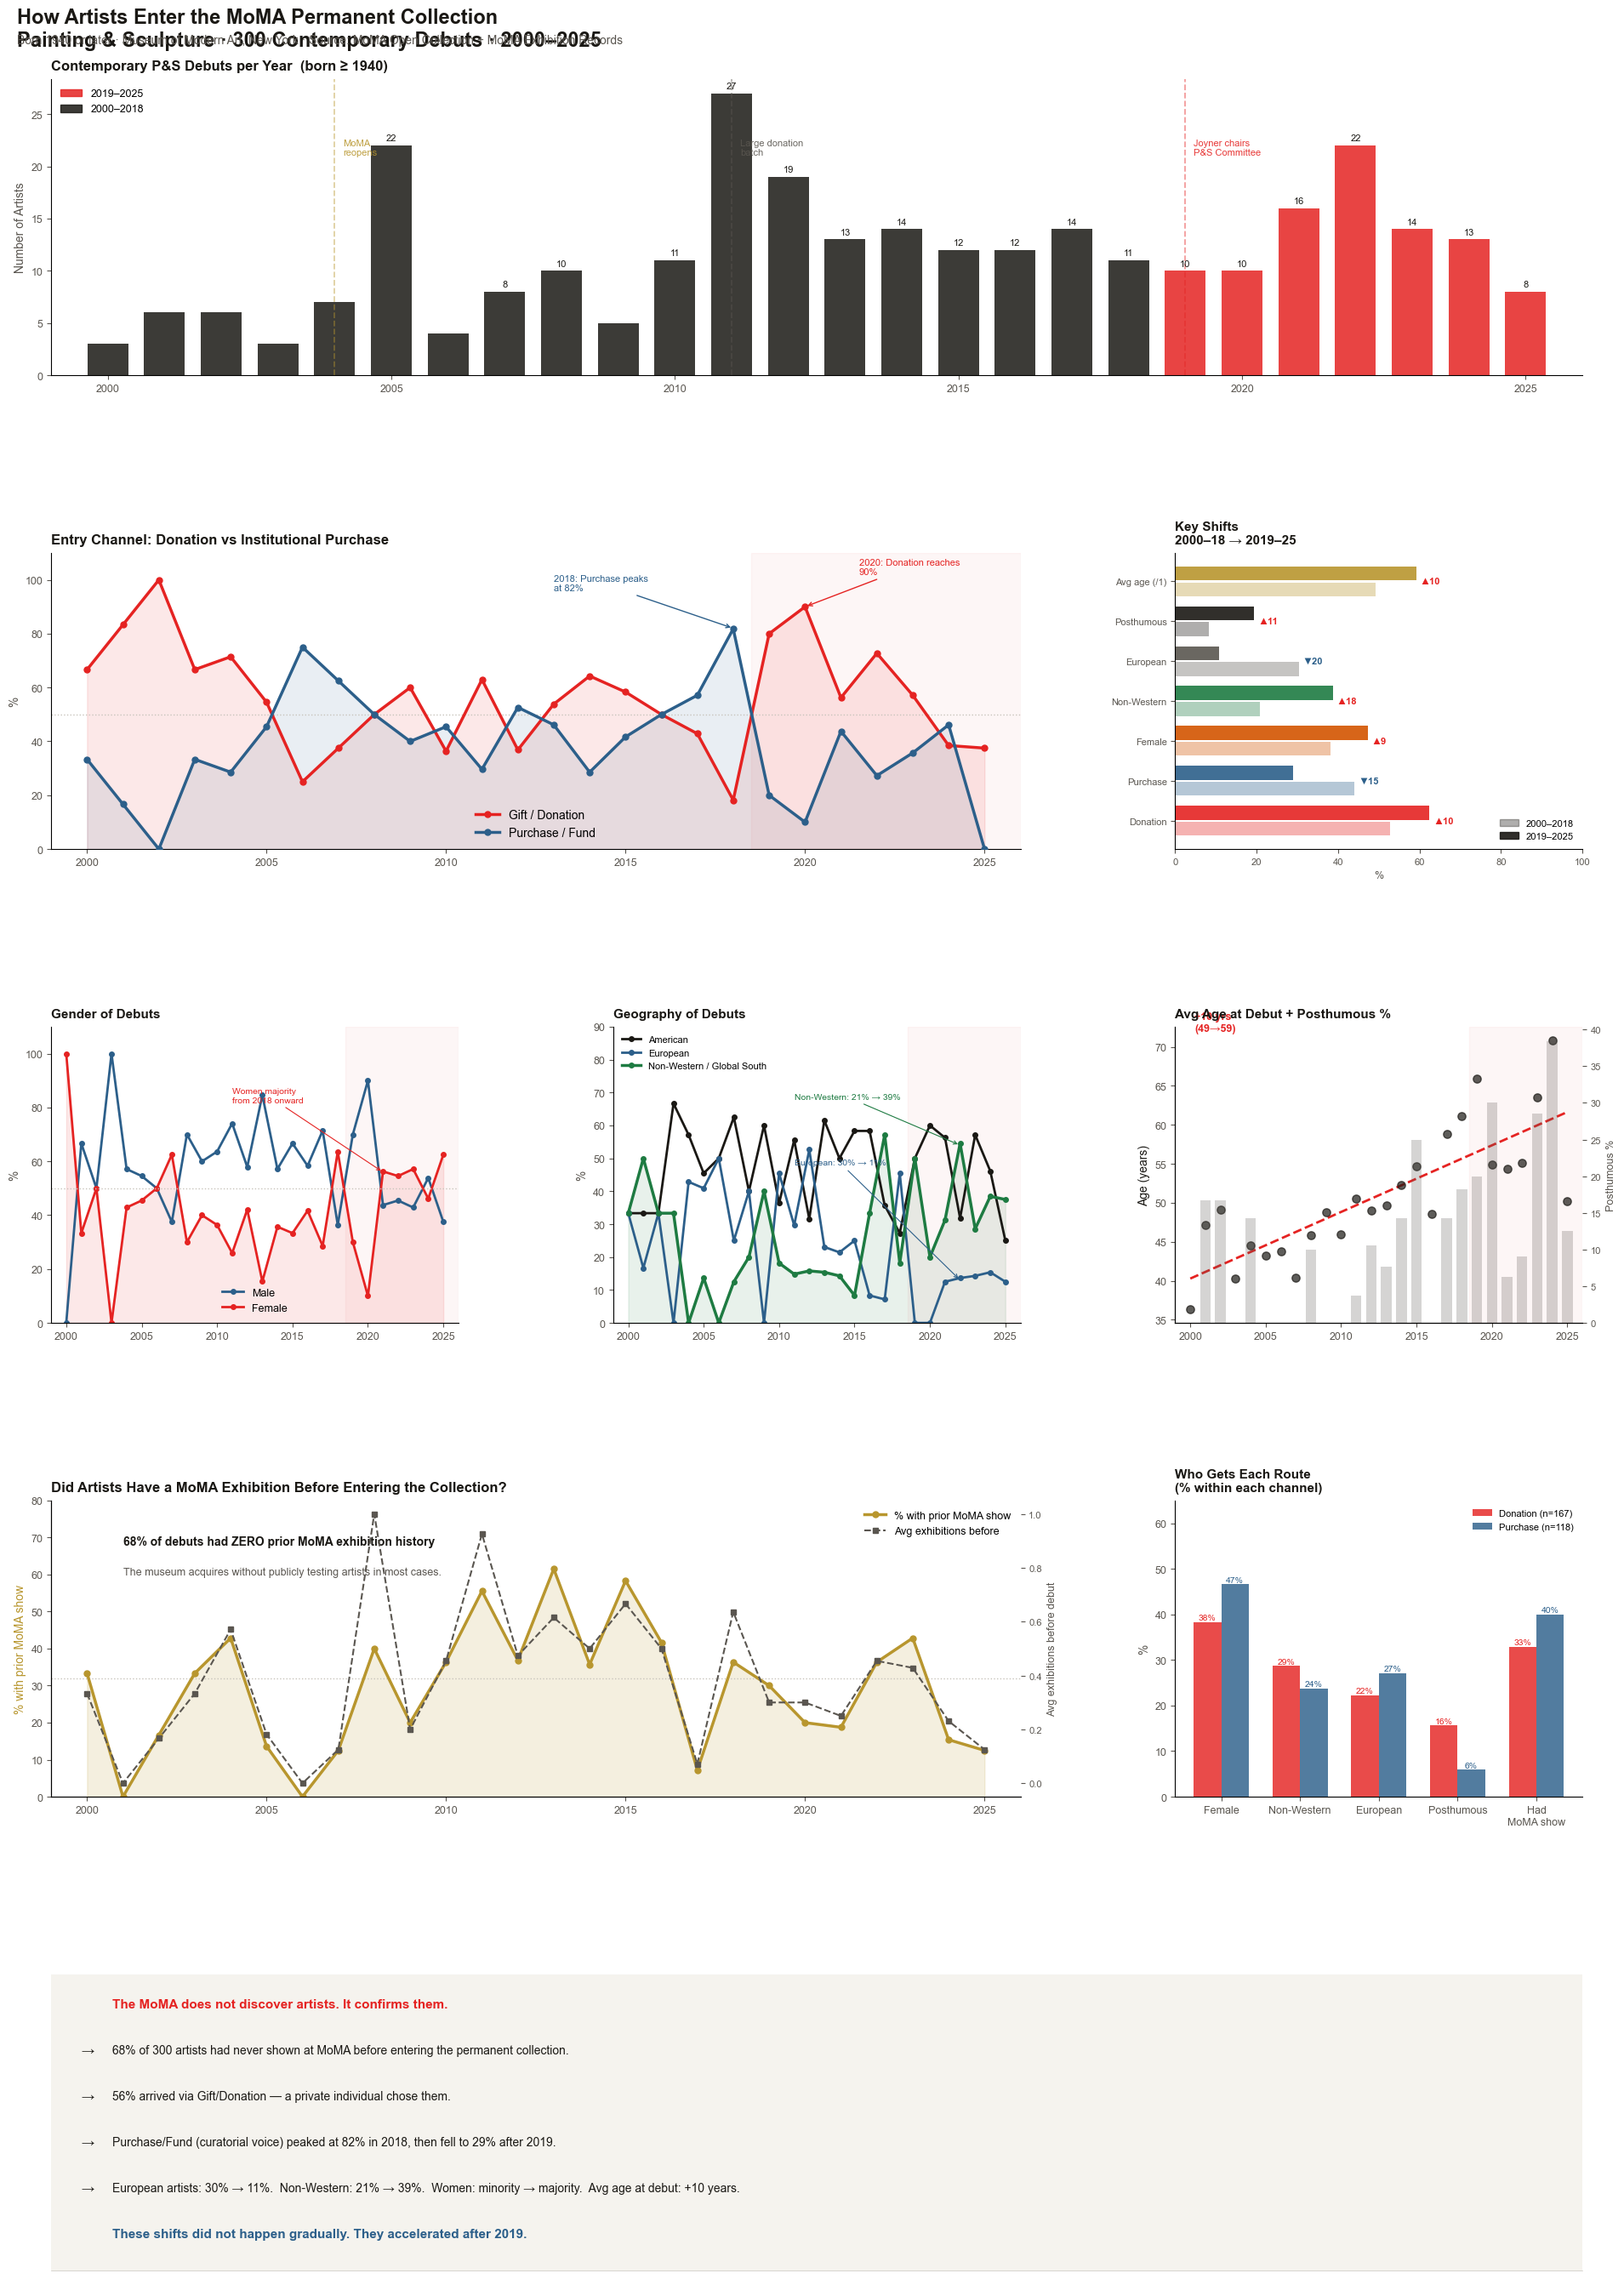

Saved: ps_final_analysis.png


In [48]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import numpy as np

RED    = '#E52322'
DARK   = '#1A1814'
MID    = '#5A5650'
LIGHT  = '#C8C4BC'
GOLD   = '#B8962E'
BLUE   = '#2C5F8A'
GREEN  = '#1E7B42'
ORANGE = '#D35400'
PALE   = '#F5F3EE'

fig = plt.figure(figsize=(20, 28), facecolor='white')
fig.suptitle(
    'How Artists Enter the MoMA Permanent Collection\n'
    'Painting & Sculpture · 300 Contemporary Debuts · 2000–2025',
    fontsize=17, fontweight='bold', color=DARK,
    y=0.99, x=0.05, ha='left'
)
fig.text(0.05, 0.975,
         'Born 1940 or later · Museum of Modern Art, New York · '
         'Source: MoMA Open Collection + MoMA Exhibition Records',
         fontsize=10, color=MID, ha='left')

gs = GridSpec(5, 3, figure=fig,
              hspace=0.6, wspace=0.38,
              top=0.96, bottom=0.04,
              left=0.07, right=0.97)

years = by_year['first_year'].values

# ── 1. DEBUTS PER YEAR ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
col_bars = [RED if y >= 2019 else DARK for y in years]
bars = ax1.bar(years, by_year['n'], color=col_bars, alpha=0.85, width=0.72)
ax1.set_title('Contemporary P&S Debuts per Year  (born ≥ 1940)',
              fontsize=12, fontweight='bold', color=DARK, loc='left', pad=8)
ax1.set_ylabel('Number of Artists', color=MID, fontsize=10)
ax1.set_xlim(1999, 2026)
ax1.tick_params(colors=MID, labelsize=9)
for bar, val in zip(bars, by_year['n']):
    if val >= 8:
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 str(int(val)), ha='center', va='bottom', fontsize=8, color=DARK)
for xv, txt, col, yf in [
    (2004, 'MoMA\nreopens', GOLD, 0.80),
    (2011, 'Large donation\nbatch', MID, 0.80),
    (2019, 'Joyner chairs\nP&S Committee', RED, 0.80),
]:
    ax1.axvline(xv, color=col, linestyle='--', alpha=0.45, linewidth=1.3)
    ax1.text(xv+0.15, ax1.get_ylim()[1]*yf, txt,
             fontsize=8, color=col, va='top', alpha=0.9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_facecolor('white')
p1 = mpatches.Patch(color=RED, alpha=0.85, label='2019–2025')
p2 = mpatches.Patch(color=DARK, alpha=0.85, label='2000–2018')
ax1.legend(handles=[p1, p2], fontsize=9, frameon=False, loc='upper left')

# ── 2. ENTRY TYPE OVER TIME ────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :2])
ax2.fill_between(years, by_year['pct_donation'], alpha=0.10, color=RED)
ax2.fill_between(years, by_year['pct_purchase'], alpha=0.10, color=BLUE)
ax2.plot(years, by_year['pct_donation'], color=RED, lw=2.5,
         label='Gift / Donation', marker='o', ms=5, zorder=3)
ax2.plot(years, by_year['pct_purchase'], color=BLUE, lw=2.5,
         label='Purchase / Fund', marker='o', ms=5, zorder=3)
ax2.axhline(50, color=LIGHT, ls=':', lw=1)
ax2.axvspan(2018.5, 2026, alpha=0.04, color=RED)
ax2.set_title('Entry Channel: Donation vs Institutional Purchase',
              fontsize=12, fontweight='bold', color=DARK, loc='left', pad=8)
ax2.set_ylabel('%', color=MID, fontsize=10)
ax2.set_ylim(0, 110)
ax2.set_xlim(1999, 2026)
ax2.legend(fontsize=10, frameon=False)
ax2.tick_params(colors=MID, labelsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_facecolor('white')
ax2.annotate('2018: Purchase peaks\nat 82%', xy=(2018, 82),
             xytext=(2013, 96), fontsize=8, color=BLUE,
             arrowprops=dict(arrowstyle='->', color=BLUE, lw=1))
ax2.annotate('2020: Donation reaches\n90%', xy=(2020, 90),
             xytext=(2021.5, 102), fontsize=8, color=RED,
             arrowprops=dict(arrowstyle='->', color=RED, lw=1))

# ── 3. THE SHIFT SUMMARY ───────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
ax3.set_title('Key Shifts\n2000–18 → 2019–25',
              fontsize=11, fontweight='bold', color=DARK, loc='left', pad=8)
metrics = [
    ('Donation',     52.7, 62.4, RED),
    ('Purchase',     44.0, 29.0, BLUE),
    ('Female',       38.2, 47.3, ORANGE),
    ('Non-Western',  20.8, 38.7, GREEN),
    ('European',     30.4, 10.8, MID),
    ('Posthumous',    8.2, 19.4, DARK),
    ('Avg age (/1)', 49.2, 59.2, GOLD),
]
for i, (label, pre, post, col) in enumerate(metrics):
    ax3.barh(i-0.2, pre,  height=0.35, color=col, alpha=0.35)
    ax3.barh(i+0.2, post, height=0.35, color=col, alpha=0.90)
    delta = post - pre
    arrow = '▲' if delta > 0 else '▼'
    ax3.text(max(pre, post)+1, i, f"{arrow}{abs(delta):.0f}",
             va='center', fontsize=8, fontweight='bold',
             color=RED if delta > 0 else BLUE)
ax3.set_yticks(range(len(metrics)))
ax3.set_yticklabels([m[0] for m in metrics], fontsize=9, color=DARK)
ax3.set_xlim(0, 100)
ax3.set_xlabel('%', color=MID, fontsize=9)
ax3.tick_params(colors=MID, labelsize=8)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.set_facecolor('white')
lp = mpatches.Patch(alpha=0.35, color=DARK, label='2000–2018')
dp = mpatches.Patch(alpha=0.90, color=DARK, label='2019–2025')
ax3.legend(handles=[lp, dp], fontsize=8, frameon=False, loc='lower right')

# ── 4. GENDER OVER TIME ───────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
ax4.fill_between(years, by_year['pct_female'], alpha=0.10, color=RED)
ax4.plot(years, by_year['pct_male'],   color=BLUE, lw=2,
         label='Male', marker='o', ms=4)
ax4.plot(years, by_year['pct_female'], color=RED,  lw=2,
         label='Female', marker='o', ms=4)
ax4.axhline(50, color=LIGHT, ls=':', lw=1)
ax4.axvspan(2018.5, 2026, alpha=0.04, color=RED)
ax4.set_title('Gender of Debuts',
              fontsize=11, fontweight='bold', color=DARK, loc='left', pad=8)
ax4.set_ylabel('%', color=MID, fontsize=10)
ax4.set_ylim(0, 110)
ax4.set_xlim(1999, 2026)
ax4.legend(fontsize=9, frameon=False)
ax4.tick_params(colors=MID, labelsize=9)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.set_facecolor('white')
ax4.annotate('Women majority\nfrom 2018 onward',
             xy=(2021, 56), xytext=(2011, 82),
             fontsize=7.5, color=RED,
             arrowprops=dict(arrowstyle='->', color=RED, lw=0.8))

# ── 5. GEOGRAPHY OVER TIME ────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
ax5.plot(years, by_year['pct_american'], color=DARK,  lw=2,
         label='American', marker='o', ms=4)
ax5.plot(years, by_year['pct_european'], color=BLUE,  lw=2,
         label='European', marker='o', ms=4)
ax5.plot(years, by_year['pct_nonwest'],  color=GREEN,  lw=2.5,
         label='Non-Western / Global South', marker='o', ms=4)
ax5.fill_between(years, by_year['pct_nonwest'], alpha=0.10, color=GREEN)
ax5.axvspan(2018.5, 2026, alpha=0.04, color=RED)
ax5.set_title('Geography of Debuts',
              fontsize=11, fontweight='bold', color=DARK, loc='left', pad=8)
ax5.set_ylabel('%', color=MID, fontsize=10)
ax5.set_ylim(0, 90)
ax5.set_xlim(1999, 2026)
ax5.legend(fontsize=8, frameon=False)
ax5.tick_params(colors=MID, labelsize=9)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.set_facecolor('white')
ax5.annotate('European: 30% → 11%',
             xy=(2022, 13), xytext=(2011, 48),
             fontsize=7.5, color=BLUE,
             arrowprops=dict(arrowstyle='->', color=BLUE, lw=0.8))
ax5.annotate('Non-Western: 21% → 39%',
             xy=(2022, 54), xytext=(2011, 68),
             fontsize=7.5, color=GREEN,
             arrowprops=dict(arrowstyle='->', color=GREEN, lw=0.8))

# ── 6. AGE + POSTHUMOUS ───────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
valid = by_year[by_year['avg_age'].notna()]
ax6_twin = ax6.twinx()
ax6_twin.bar(years, by_year['pct_posthumous'],
             color=MID, alpha=0.25, width=0.7, label='Posthumous %')
ax6.scatter(valid['first_year'], valid['avg_age'],
            color=DARK, alpha=0.7, s=45, zorder=4)
x = valid['first_year'].values
y_a = valid['avg_age'].values
from numpy.polynomial.polynomial import polyfit
c = polyfit(x, y_a, 1)
ax6.plot(x, c[0]+c[1]*x, color=RED, lw=2, ls='--', label='Age trend', zorder=3)
ax6.axvspan(2018.5, 2026, alpha=0.04, color=RED)
ax6.set_title('Avg Age at Debut + Posthumous %',
              fontsize=11, fontweight='bold', color=DARK, loc='left', pad=8)
ax6.set_ylabel('Age (years)', color=DARK, fontsize=10)
ax6_twin.set_ylabel('Posthumous %', color=MID, fontsize=9)
ax6.set_xlim(1999, 2026)
ax6.tick_params(colors=MID, labelsize=9)
ax6_twin.tick_params(colors=MID, labelsize=8)
ax6.spines['top'].set_visible(False)
ax6.set_facecolor('white')
ax6.text(2000.3, 72, '+10 yrs\n(49→59)',
         fontsize=9, color=RED, fontweight='bold')

# ── 7. EXHIBITION HISTORY BEFORE DEBUT ────────────────────────
ax7 = fig.add_subplot(gs[3, :2])

# Build by year: % with prior MoMA show
by_year_exh = focus.groupby('first_year').agg(
    pct_had_show=('had_moma_show_before', lambda x: x.mean()*100),
    avg_exh_before=('n_exhibitions_before', 'mean'),
).reset_index()

ax7b = ax7.twinx()
ax7.fill_between(by_year_exh['first_year'],
                 by_year_exh['pct_had_show'],
                 alpha=0.15, color=GOLD)
ax7.plot(by_year_exh['first_year'], by_year_exh['pct_had_show'],
         color=GOLD, lw=2.5, marker='o', ms=5,
         label='% with prior MoMA show', zorder=3)
ax7b.plot(by_year_exh['first_year'], by_year_exh['avg_exh_before'],
          color=MID, lw=1.5, ls='--', marker='s', ms=4,
          label='Avg exhibitions before', zorder=2)
ax7.axhline(32, color=LIGHT, ls=':', lw=1)
ax7.set_title('Did Artists Have a MoMA Exhibition Before Entering the Collection?',
              fontsize=12, fontweight='bold', color=DARK, loc='left', pad=8)
ax7.set_ylabel('% with prior MoMA show', color=GOLD, fontsize=10)
ax7b.set_ylabel('Avg exhibitions before debut', color=MID, fontsize=9)
ax7.set_ylim(0, 80)
ax7.set_xlim(1999, 2026)
ax7.tick_params(colors=MID, labelsize=9)
ax7b.tick_params(colors=MID, labelsize=8)
ax7.spines['top'].set_visible(False)
ax7.set_facecolor('white')
lines1, labs1 = ax7.get_legend_handles_labels()
lines2, labs2 = ax7b.get_legend_handles_labels()
ax7.legend(lines1+lines2, labs1+labs2, fontsize=9, frameon=False)
ax7.text(2001, 68,
         '68% of debuts had ZERO prior MoMA exhibition history',
         fontsize=10, color=DARK, fontweight='bold')
ax7.text(2001, 60,
         'The museum acquires without publicly testing artists in most cases.',
         fontsize=9, color=MID)

# ── 8. DONATION vs PURCHASE: who gets each route ──────────────
ax8 = fig.add_subplot(gs[3, 2])
cats = ['Female', 'Non-Western', 'European', 'Posthumous', 'Had\nMoMA show']
don_v = [38.3, 28.7, 22.2, 15.6, 32.9]
pur_v = [46.6, 23.7, 27.1,  5.9, 40.0]
xp = np.arange(len(cats))
w = 0.35
b1 = ax8.bar(xp-w/2, don_v, w, color=RED,  alpha=0.82, label='Donation (n=167)')
b2 = ax8.bar(xp+w/2, pur_v, w, color=BLUE, alpha=0.82, label='Purchase (n=118)')
ax8.set_title('Who Gets Each Route\n(% within each channel)',
              fontsize=11, fontweight='bold', color=DARK, loc='left', pad=8)
ax8.set_xticks(xp)
ax8.set_xticklabels(cats, fontsize=9)
ax8.set_ylabel('%', color=MID, fontsize=10)
ax8.set_ylim(0, 65)
ax8.legend(fontsize=8, frameon=False)
ax8.tick_params(colors=MID, labelsize=9)
ax8.spines['top'].set_visible(False)
ax8.spines['right'].set_visible(False)
ax8.set_facecolor('white')
for bar in b1:
    ax8.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f"{bar.get_height():.0f}%", ha='center', fontsize=7.5, color=RED)
for bar in b2:
    ax8.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f"{bar.get_height():.0f}%", ha='center', fontsize=7.5, color=BLUE)

# ── 9. CENTRAL FINDING BOX ───────────────────────────────────
ax9 = fig.add_subplot(gs[4, :])
ax9.set_facecolor(PALE)
ax9.spines['top'].set_linewidth(2)
ax9.spines['top'].set_color(RED)
ax9.spines['bottom'].set_linewidth(0.5)
ax9.spines['bottom'].set_color(LIGHT)
ax9.spines['left'].set_visible(False)
ax9.spines['right'].set_visible(False)
ax9.set_xticks([])
ax9.set_yticks([])

findings = [
    ("The MoMA does not discover artists. It confirms them.",
     True, RED),
    ("68% of 300 artists had never shown at MoMA before entering the permanent collection.",
     False, DARK),
    ("56% arrived via Gift/Donation — a private individual chose them.",
     False, DARK),
    ("Purchase/Fund (curatorial voice) peaked at 82% in 2018, then fell to 29% after 2019.",
     False, DARK),
    ("European artists: 30% → 11%.  Non-Western: 21% → 39%.  "
     "Women: minority → majority.  Avg age at debut: +10 years.",
     False, DARK),
    ("These shifts did not happen gradually. They accelerated after 2019.",
     True, BLUE),
]

y_pos = 0.92
for text, bold, color in findings:
    ax9.text(0.02, y_pos, ("→ " if not bold else ""), fontsize=11,
             color=color, transform=ax9.transAxes, va='top')
    ax9.text(0.04, y_pos, text, fontsize=11 if bold else 10,
             fontweight='bold' if bold else 'normal',
             color=color, transform=ax9.transAxes, va='top')
    y_pos -= 0.155

plt.savefig('/Users/arousell/data/ps_final_analysis.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: ps_final_analysis.png")

In [7]:
import re

exh_list3 = []
for exh in exhibitions_raw:
    if not exh.get('artists'):
        continue
    
    # Extract year from date string like "Apr 18–Jun 22, 1975"
    date_str = exh.get('date', '')
    year_match = re.search(r'\b(19|20)\d{2}\b', date_str)
    year = int(year_match.group()) if year_match else None
    
    for artist in exh['artists']:
        artist_name = artist.get('name', '') if isinstance(artist, dict) else str(artist)
        artist_id = artist.get('id', '') if isinstance(artist, dict) else ''
        
        exh_list3.append({
            'exhibition_id': exh.get('id'),
            'exhibition_title': exh.get('title', ''),
            'year': year,
            'artist_name': artist_name,
            'artist_id': artist_id
        })

exh_df = pd.DataFrame(exh_list3)
print(f"Total records: {len(exh_df)}")
print(f"Date range: {exh_df['year'].min()} - {exh_df['year'].max()}")
print(f"\nPost-2019 exhibitions:")
print(exh_df[exh_df['year'] >= 2019]['artist_name'].value_counts().head(20))

Total records: 8291
Date range: 1929.0 - 2026.0

Post-2019 exhibitions:
artist_name
Various Artists      4
Henri Matisse        4
Joan Miró            3
Andy Warhol          3
Joan Jonas           3
Pablo Picasso        3
Louise Bourgeois     2
Betye Saar           2
David Hammons        2
Senga Nengudi        2
Sable Elyse Smith    2
Ulrike Müller        2
Formafantasma        2
Claude Cahun         2
Frida Kahlo          2
Meret Oppenheim      2
Carolina Caycedo     2
Jim Dine             2
Aaron Horkey         2
Fototeca Gildari     2
Name: count, dtype: int64


In [8]:
# Cross-reference exhibitions with our 90 contemporary debut artists
contemporary_names = set(contemporary['Artist'].tolist())

# Find which of our 90 appeared in exhibitions BEFORE their MoMA debut
results = []
for _, artist_row in contemporary.iterrows():
    name = artist_row['Artist']
    debut_year = artist_row['DebutYear']
    
    # Find exhibitions for this artist
    artist_exh = exh_df[exh_df['artist_name'] == name]
    
    before = artist_exh[artist_exh['year'] < debut_year]
    after = artist_exh[artist_exh['year'] >= debut_year]
    
    results.append({
        'artist': name,
        'debut_year': debut_year,
        'exhibitions_before': len(before),
        'exhibitions_after': len(after),
        'first_exhibition': before['year'].min() if len(before) > 0 else None,
        'exhibition_titles_before': ', '.join(before['exhibition_title'].tolist()[:3])
    })

results_df = pd.DataFrame(results)

# Summary
had_exh_before = results_df[results_df['exhibitions_before'] > 0]
print(f"Total contemporary debuts: {len(results_df)}")
print(f"Had MoMA exhibition BEFORE acquisition: {len(had_exh_before)} ({len(had_exh_before)/len(results_df)*100:.1f}%)")
print(f"No prior MoMA exhibition: {len(results_df) - len(had_exh_before)}")
print(f"\nArtists with prior MoMA exhibitions:")
print(had_exh_before[['artist', 'debut_year', 'first_exhibition', 'exhibitions_before', 'exhibition_titles_before']].to_string())

Total contemporary debuts: 90
Had MoMA exhibition BEFORE acquisition: 16 (17.8%)
No prior MoMA exhibition: 74

Artists with prior MoMA exhibitions:
                  artist  debut_year  first_exhibition  exhibitions_before                                                                                            exhibition_titles_before
4             Anne Imhof      2023.0            2015.0                   1                                                                                                    Anne Imhof: DEAL
6    Bodys Isek Kingelez      2019.0            2018.0                   1                                                                                  Bodys Isek Kingelez\n\nCity Dreams
10               Cui Jie      2021.0            2017.0                   1                                                                                                           Past Skin
21          Helen Marten      2022.0            2012.0                   1              

In [9]:
# Merge with credit line data for the 74 without prior exhibitions
no_prior_exh = results_df[results_df['exhibitions_before'] == 0]['artist'].tolist()

# Get their acquisition info
acq_info = ps.copy()
acq_info['DateAcquired'] = pd.to_datetime(acq_info['DateAcquired'], errors='coerce')
acq_info['YearAcquired'] = acq_info['DateAcquired'].dt.year

# First acquisition per artist
first_acq = acq_info.groupby('Artist').agg(
    YearAcquired=('YearAcquired', 'min'),
    CreditLine=('CreditLine', 'first')
).reset_index()

no_prior_df = first_acq[first_acq['Artist'].isin(no_prior_exh)].copy()

# Classify acquisition type
def classify(cl):
    cl = str(cl).lower()
    if 'gift' in cl:
        return 'DONATION'
    elif 'purchase' in cl or 'fund' in cl:
        return 'PURCHASE/FUND'
    elif 'promised' in cl:
        return 'PROMISED GIFT'
    elif 'bequest' in cl:
        return 'BEQUEST'
    else:
        return 'OTHER'

no_prior_df['AcqType'] = no_prior_df['CreditLine'].apply(classify)

print(f"Artists with NO prior MoMA exhibition: {len(no_prior_df)}")
print(f"\nBy acquisition type:")
print(no_prior_df['AcqType'].value_counts())
print(f"\nBreakdown:")
for acq_type in no_prior_df['AcqType'].unique():
    subset = no_prior_df[no_prior_df['AcqType'] == acq_type]
    print(f"\n--- {acq_type} ({len(subset)}) ---")
    for _, row in subset.iterrows():
        print(f"  {row['Artist']}: {str(row['CreditLine'])[:80]}")

Artists with NO prior MoMA exhibition: 74

By acquisition type:
AcqType
DONATION         48
PURCHASE/FUND    21
OTHER             5
Name: count, dtype: int64

Breakdown:

--- PURCHASE/FUND (21) ---
  Abdoulaye Konaté: Committee on Painting and Sculpture Funds
  Analia Saban: Latin American and Caribbean Fund
  Anne Chu: Acquired through the generosity of Anne and Joel Ehrenkranz and Committee on Pai
  Christine Sun Kim: Fund for the Twenty-First Century
  David Diao: Committee on Painting and Sculpture Funds
  Diamond Stingily: Fund for the Twenty-First Century

  Fernanda Gomes: Latin American and Caribbean Fund
  Guadalupe Maravilla: Fund for the Twenty-First Century
  Jana Euler: Fund for the Twenty-First Century
  Lauren Halsey: The Jill and Peter Kraus Endowed Fund for Contemporary Acquisitions
  Marwan Rechmaoui: Fund for the Twenty-First Century
  Monika Baer: Fund for the Twenty-First Century
  Nike Davies-Okundaye: Painting and Sculpture Deaccession Funds
  Rochelle Feinstein:

In [10]:
# Who are the recurring donors in P&S debuts 2019-2026?
# And how many artists does each bring?
print("=== RECURRING DONORS IN P&S DEBUTS 2019-2026 ===\n")

# Extract individual donor names from CreditLine
import re

def extract_donors(text):
    if pd.isna(text):
        return []
    # Remove common prefixes
    text = re.sub(r'Gift of |Acquired through the generosity of |Bequest of |Purchase of ', '', text)
    text = re.sub(r' in honor of .*', '', text)
    text = re.sub(r' in memory of .*', '', text)
    text = re.sub(r'\(by exchange\)', '', text)
    # Split by common separators
    donors = re.split(r',\s*and\s*|\s*and\s*|;\s*', text)
    return [d.strip() for d in donors if len(d.strip()) > 3]

ps_debuts['Donors'] = ps_debuts['CreditLine'].apply(extract_donors)

# Count artist debuts per donor
donor_artist_count = {}
for _, row in ps_debuts.iterrows():
    for donor in row['Donors']:
        if donor not in donor_artist_count:
            donor_artist_count[donor] = []
        donor_artist_count[donor].append(row['Artist'])

# Sort by count
donor_artist_count = {k: v for k, v in 
                      sorted(donor_artist_count.items(), 
                             key=lambda x: len(x[1]), reverse=True)}

print(f"{'Donor':<50} {'Artists':>8}")
print("-" * 70)
for donor, artists in list(donor_artist_count.items())[:20]:
    print(f"{donor[:50]:<50} {len(artists):>8}")
    for artist in artists:
        print(f"  → {artist}")

=== RECURRING DONORS IN P&S DEBUTS 2019-2026 ===



NameError: name 'ps_debuts' is not defined

In [ ]:
# Who repeats as donor/fund
from collections import Counter

creditlines = debuts['CreditLine'].dropna().tolist()

# Search for recurring key names
keywords = [
    'Joyner', 'Tisch', 'Kravis', 'Tamer', 'Gund', 
    'Ehrenkranz', 'Dubin', 'Twenty-First Century', 
    'Latin American', 'Kraus', 'Cohen', 'Tananbaum',
    'Heyman', 'Pigozzi', 'Weir', 'Rockefeller',
    'Anonymous', 'Purchase', 'Deaccession', 'Haupt',
    'Paley', 'Lewisohn', 'Heinz', 'Ovitz', 'Ebers'
]

print("=== FREQUENCY BY KEY NAME (147 artists) ===")
for kw in keywords:
    count = sum(1 for cl in creditlines if kw in str(cl))
    artists = [debuts.iloc[i]['Artist'] for i, cl in enumerate(debuts['CreditLine'].tolist()) if kw in str(cl)]
    print(f"\n  {kw}: {count}x")
    for a in artists:
        print(f"    - {a}")